In [145]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import functions_spin_p as fy
from importlib import reload

reload(fy)

<module 'functions_spin_p' from '/mnt/c/Users/frnkl/Desktop/thesis_spin_caloritronics/tesis_models/Geyer_Site_Dots/functions_spin_p.py'>

In [146]:
import spin_thermoelectric_coefficients as th
reload(th)

<module 'spin_thermoelectric_coefficients' from '/mnt/c/Users/frnkl/Desktop/thesis_spin_caloritronics/tesis_models/Geyer_Site_Dots/spin_thermoelectric_coefficients.py'>

In [147]:
#Energy axis

energy_axis = np.arange(-6, 6 + 0.01, 0.01) #meV
print("Energy axis is", energy_axis,"meV")

#Gamma i.e. width parameter
gamma = 0.5 #meV
print("The width is:",gamma,"meV")

#Site energies:
e_01 = 0 #meV
e_02 = 0 #meV
e_11 = 1 #meV
e_12 = 1 #meV

# Interdot Hopping
t = 7*gamma #meV

# Helix geometric parameters:

lam_2 = 0.5 #meV

B = - 2

k= 0.4


Energy axis is [-6.   -5.99 -5.98 ...  5.98  5.99  6.  ] meV
The width is: 0.5 meV


# Extended Michaeli - Geyer

In [148]:
#More Parameters
temperature = 3 #Kelvin
print("T is:", temperature,"Kelvin")

fermi_axis = np.arange(-6, 6 + 0.01, 0.01) #meV
print("Fermi Energy axis is", fermi_axis,"meV")

T is: 3 Kelvin
Fermi Energy axis is [-6.   -5.99 -5.98 ...  5.98  5.99  6.  ] meV


In [149]:
L = 1
#Intradot Hopping parameter:
om = k*gamma #meV

#Renormalized site energies array:
e_ren_1_u = np.array([e_01,e_11, om])
e_ren_1_d = np.array([e_01,e_11, om])

e_ren_2_u = np.array([e_02, e_12, om])
e_ren_2_d = np.array([e_02, e_12, om])


site_energies = np.array([e_ren_1_u, e_ren_1_d , e_ren_2_u , e_ren_2_d], dtype = complex)

Hamiltonian = np.array([[ lam_2*L*B, -(1j)*lam_2*L*B,-t,0],[(1j)*lam_2*L*B, -lam_2*L*B, 0,-t],[-t,0, lam_2*L*B, -(1j)*lam_2*L*B],\
                        [0,-t, (1j)*lam_2*L*B, -lam_2*L*B]], dtype = complex)

print(Hamiltonian)

[[-1. +0.j  0. +1.j -3.5+0.j  0. +0.j]
 [-0. -1.j  1. +0.j  0. +0.j -3.5+0.j]
 [-3.5+0.j  0. +0.j -1. +0.j  0. +1.j]
 [ 0. +0.j -3.5+0.j -0. -1.j  1. +0.j]]


In [150]:
#POLARIZATION UP-UP
p_L_1 = 1
p_R_1 = 0

#Transmission axis

transmission_u_1 = fy.Transmission(energy_axis,gamma, Hamiltonian, site_energies, p_L_1, p_R_1)[0]
transmission_d_1 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_1, p_R_1)[1]

#Thermopower
seebeck_1 = th.S(fermi_axis, temperature, energy_axis, p_L_1, p_R_1, gamma, Hamiltonian, site_energies)
seebeck_u_1 = th.S_up(fermi_axis, temperature, energy_axis, p_L_1, p_R_1, gamma, Hamiltonian, site_energies)
seebeck_d_1 = th.S_down(fermi_axis, temperature, energy_axis, p_L_1, p_R_1, gamma, Hamiltonian, site_energies)

In [151]:
#POLARIZATION UP-DOWN
p_L_2 = -1
p_R_2 = 0

#Transmission axis

transmission_u_2 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_2, p_R_2)[0]
transmission_d_2 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_2, p_R_2)[1]

#Thermopower
seebeck_2 = th.S(fermi_axis, temperature, energy_axis, p_L_2, p_R_2, gamma, Hamiltonian, site_energies)
seebeck_u_2 = th.S_up(fermi_axis, temperature, energy_axis, p_L_2, p_R_2, gamma, Hamiltonian, site_energies)
seebeck_d_2 = th.S_down(fermi_axis, temperature, energy_axis, p_L_2, p_R_2, gamma, Hamiltonian, site_energies)

In [152]:
# Definir la función sigmoide para suavizar el corte
def sigmoid_cutoff(values, energy, cutoff=4, width=0.5):
    factor = 1 / (1 + np.exp((np.abs(energy) - cutoff) / width))
    return values * factor


In [153]:
# Aplicar cutoff suave a seebeck_1, seebeck_u_1 y seebeck_d_1
seebeck_1 = sigmoid_cutoff(seebeck_1, fermi_axis)
seebeck_u_1 = sigmoid_cutoff(seebeck_u_1, fermi_axis)
seebeck_d_1 = sigmoid_cutoff(seebeck_d_1, fermi_axis)

# Aplicar cutoff suave a seebeck_2, seebeck_u_2 y seebeck_d_2
seebeck_2 = sigmoid_cutoff(seebeck_2, fermi_axis)
seebeck_u_2 = sigmoid_cutoff(seebeck_u_2, fermi_axis)
seebeck_d_2 = sigmoid_cutoff(seebeck_d_2, fermi_axis)


/home/franklin/miniconda3/envs/py37/lib/python3.7/site-packages/ipykernel_launcher.py:66: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.


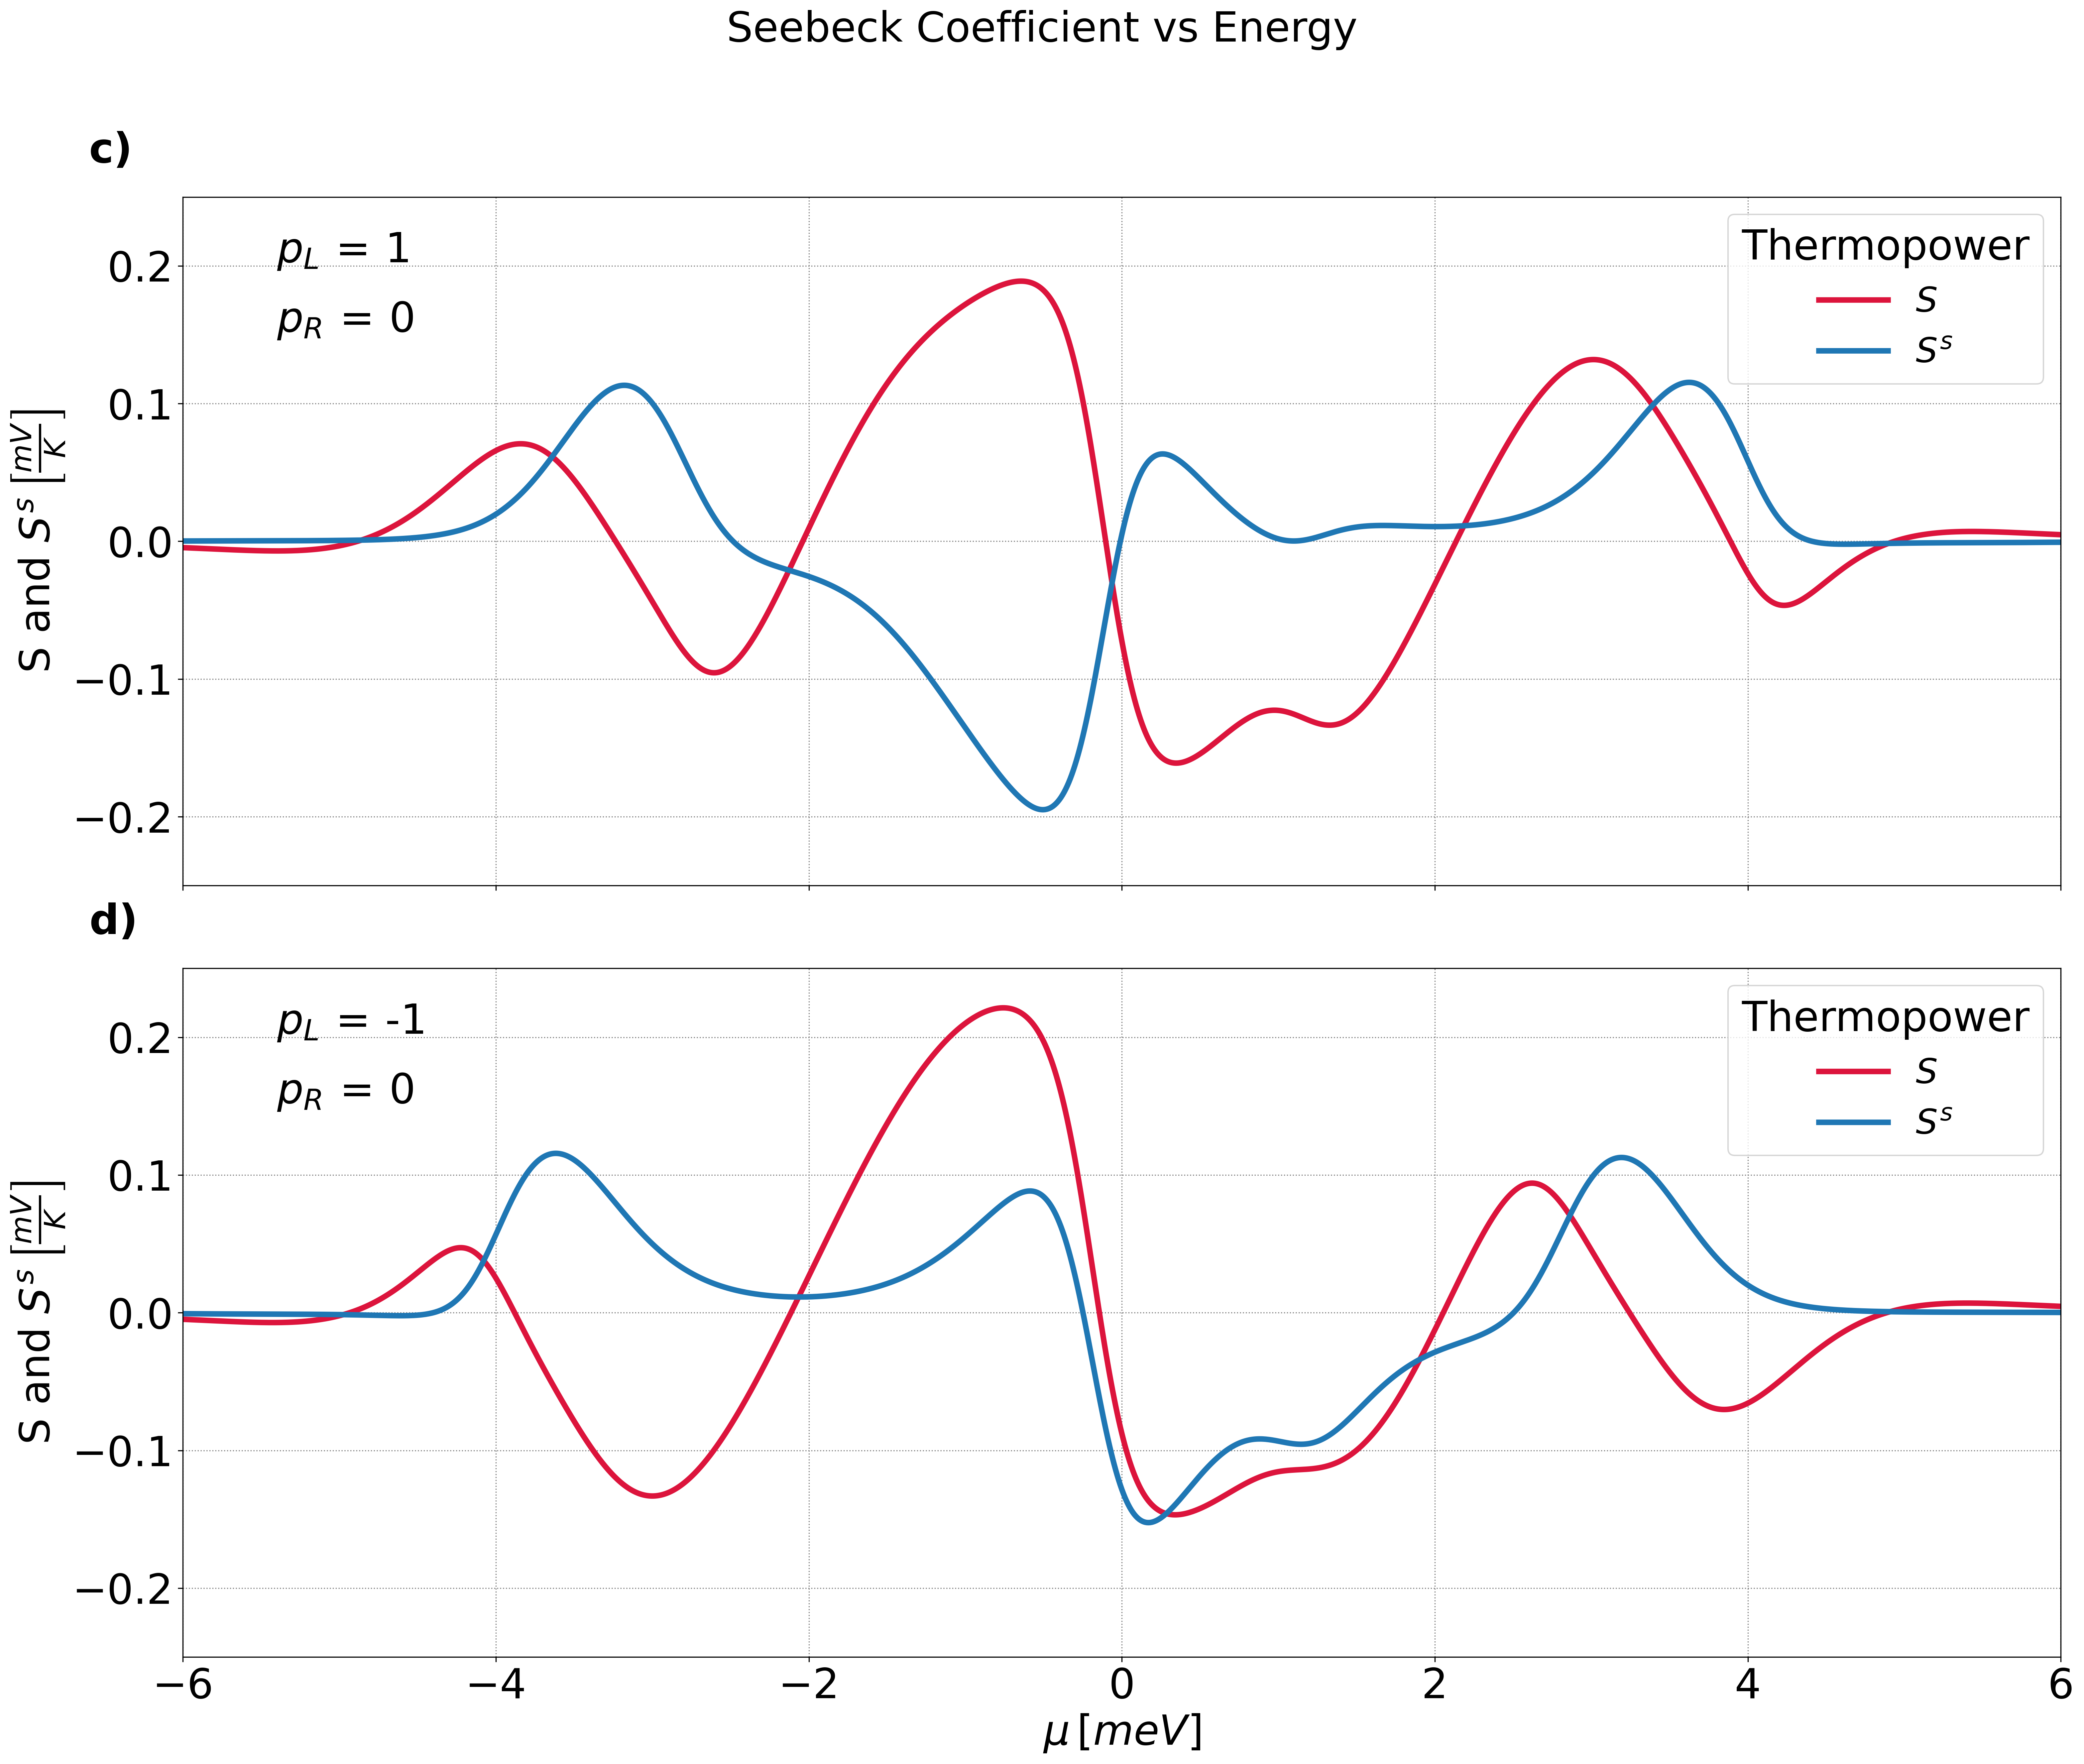

In [154]:
# Crear la figura y los ejes
fig = plt.figure(constrained_layout=True, figsize=(21, 18), dpi=300)

# these are matplotlib.patch.Patch properties
props = dict(boxstyle='round', facecolor='wheat', alpha=0)

# Set the grid for the subplots
gs = GridSpec(2, 1, figure=fig)

# Add the subplots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0])

ax1.grid(linestyle=':', color='grey')
ax1.plot(fermi_axis, -(1/2)*(seebeck_u_1 + seebeck_d_1), "#DC143C", label=r"$S$", linestyle="-", lw=4)
ax1.plot(fermi_axis, -(1/2)*(seebeck_u_1 - seebeck_d_1), "#1f77b4", label=r"$S^{s}$", linestyle="-", lw=4)
ax1.set_ylabel(r'S and $S^{s}\,\left[\frac{mV}{K} \right]$', fontsize=30)
ax1.text(0.05, 0.95, r"$p_{L}\,=\,$"+str(p_L_1), transform=ax1.transAxes, fontsize=30,
         verticalalignment='top', bbox=props)
ax1.text(0.05, 0.85, r"$p_{R}\,=\,$"+str(p_R_1), transform=ax1.transAxes, fontsize=30,
         verticalalignment='top', bbox=props)
ax1.legend(
    fontsize=25,
    title="Thermopower",
    title_fontsize=30,
    loc="upper right"
)
# Etiqueta a)
ax1.text(-0.05, 1.05, 'c)', transform=ax1.transAxes, fontsize=30, fontweight='bold')

ax2.grid(linestyle=':', color='grey')
ax2.plot(fermi_axis, -(1/2)*(seebeck_u_2 + seebeck_d_2), "#DC143C", label=r"$S$", linestyle="-", lw=4)
ax2.plot(fermi_axis, -(1/2)*(seebeck_u_2 - seebeck_d_2), "#1f77b4", label=r"$S^{s}$", linestyle="-", lw=4)
ax2.set_xlabel(r'$\mu\,[meV]$', fontsize=30)
ax2.set_ylabel(r'S and $S^{s}\,\left[\frac{mV}{K} \right]$', fontsize=30)
ax2.text(0.05, 0.95, r"$p_{L}\,=\,$"+str(p_L_2), transform=ax2.transAxes, fontsize=30,
         verticalalignment='top', bbox=props)
ax2.text(0.05, 0.85, r"$p_{R}\,=\,$"+str(p_R_2), transform=ax2.transAxes, fontsize=30,
         verticalalignment='top', bbox=props)
ax2.legend(
    fontsize=25,
    title="Thermopower",
    title_fontsize=30,
    loc="upper right"
)
# Etiqueta b)
ax2.text(-0.05, 1.05, 'd)', transform=ax2.transAxes, fontsize=30, fontweight='bold')

# Establecer límites para los subplots
ax1.set_xlim(-6, 6)
ax1.set_ylim(-0.25, 0.25)
ax2.set_xlim(-6, 6)
ax2.set_ylim(-0.25, 0.25)

# Ajustar el tamaño de las etiquetas de los ejes x e y
ax1.tick_params(axis='x', labelsize=30)
ax1.tick_params(axis='y', labelsize=30)
ax2.tick_params(axis='x', labelsize=30)
ax2.tick_params(axis='y', labelsize=30)

# Eliminar los números del eje x en el primer subplot
ax1.set_xticklabels([])

# Ajustar el diseño y mostrar los subplots
plt.suptitle("Seebeck Coefficient vs Energy", fontsize=30)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Guardar la imagen
#fig.savefig('final_thermopower_part2.jpg')

# Michaeli - Geyer

In [155]:
#More Parameters
temperature = 3 #Kelvin
print("T is:", temperature,"Kelvin")

fermi_axis = np.arange(-6, 6 + 0.01, 0.01) #meV
print("Fermi Energy axis is", fermi_axis,"meV")

T is: 3 Kelvin
Fermi Energy axis is [-6.   -5.99 -5.98 ...  5.98  5.99  6.  ] meV


In [156]:
L = 1
#Intradot Hopping parameter:
om = 0*gamma #meV

#Renormalized site energies array:
e_ren_1_u1 = np.array([e_01,e_11, om])
e_ren_1_d1 = np.array([e_01,e_11, om])

e_ren_2_u1 = np.array([e_02, e_12, om])
e_ren_2_d1 = np.array([e_02, e_12, om])


site_energies1 = np.array([e_ren_1_u1, e_ren_1_d1 , e_ren_2_u1 , e_ren_2_d1], dtype = complex)

Hamiltonian = np.array([[ lam_2*L*B, -(1j)*lam_2*L*B,-t,0],[(1j)*lam_2*L*B, -lam_2*L*B, 0,-t],[-t,0, lam_2*L*B, -(1j)*lam_2*L*B],\
                        [0,-t, (1j)*lam_2*L*B, -lam_2*L*B]], dtype = complex)

print(Hamiltonian)

[[-1. +0.j  0. +1.j -3.5+0.j  0. +0.j]
 [-0. -1.j  1. +0.j  0. +0.j -3.5+0.j]
 [-3.5+0.j  0. +0.j -1. +0.j  0. +1.j]
 [ 0. +0.j -3.5+0.j -0. -1.j  1. +0.j]]


In [157]:
#POLARIZATION UP-UP
p_L_1 = 1
p_R_1 = 0

#Transmission axis

transmission_u_11 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies1, p_L_1, p_R_1)[0]
transmission_d_11 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies1, p_L_1, p_R_1)[1]

#Thermopower
seebeck_11 = th.S(fermi_axis, temperature, energy_axis, p_L_1, p_R_1, gamma, Hamiltonian, site_energies1)
seebeck_u_11 = th.S_up(fermi_axis, temperature, energy_axis, p_L_1, p_R_1, gamma, Hamiltonian, site_energies1)
seebeck_d_11 = th.S_down(fermi_axis, temperature, energy_axis, p_L_1, p_R_1, gamma, Hamiltonian, site_energies1)

In [158]:
#POLARIZATION UP-DOWN
p_L_2 = -1
p_R_2 = 0

#Transmission axis

transmission_u_21 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies1, p_L_2, p_R_2)[0]
transmission_d_21 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies1, p_L_2, p_R_2)[1]

#Thermopower
seebeck_21 = th.S(fermi_axis, temperature, energy_axis, p_L_2, p_R_2, gamma, Hamiltonian, site_energies1)
seebeck_u_21 = th.S_up(fermi_axis, temperature, energy_axis, p_L_2, p_R_2, gamma, Hamiltonian, site_energies1)
seebeck_d_21 = th.S_down(fermi_axis, temperature, energy_axis, p_L_2, p_R_2, gamma, Hamiltonian, site_energies1)

In [159]:
# Aplicar cutoff suave a seebeck_1, seebeck_u_1 y seebeck_d_1
seebeck_11 = sigmoid_cutoff(seebeck_11, fermi_axis)
seebeck_u_11 = sigmoid_cutoff(seebeck_u_11, fermi_axis)
seebeck_d_11 = sigmoid_cutoff(seebeck_d_11, fermi_axis)

# Aplicar cutoff suave a seebeck_2, seebeck_u_2 y seebeck_d_2
seebeck_21 = sigmoid_cutoff(seebeck_21, fermi_axis)
seebeck_u_21 = sigmoid_cutoff(seebeck_u_21, fermi_axis)
seebeck_d_21 = sigmoid_cutoff(seebeck_d_21, fermi_axis)


/home/franklin/miniconda3/envs/py37/lib/python3.7/site-packages/ipykernel_launcher.py:66: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.


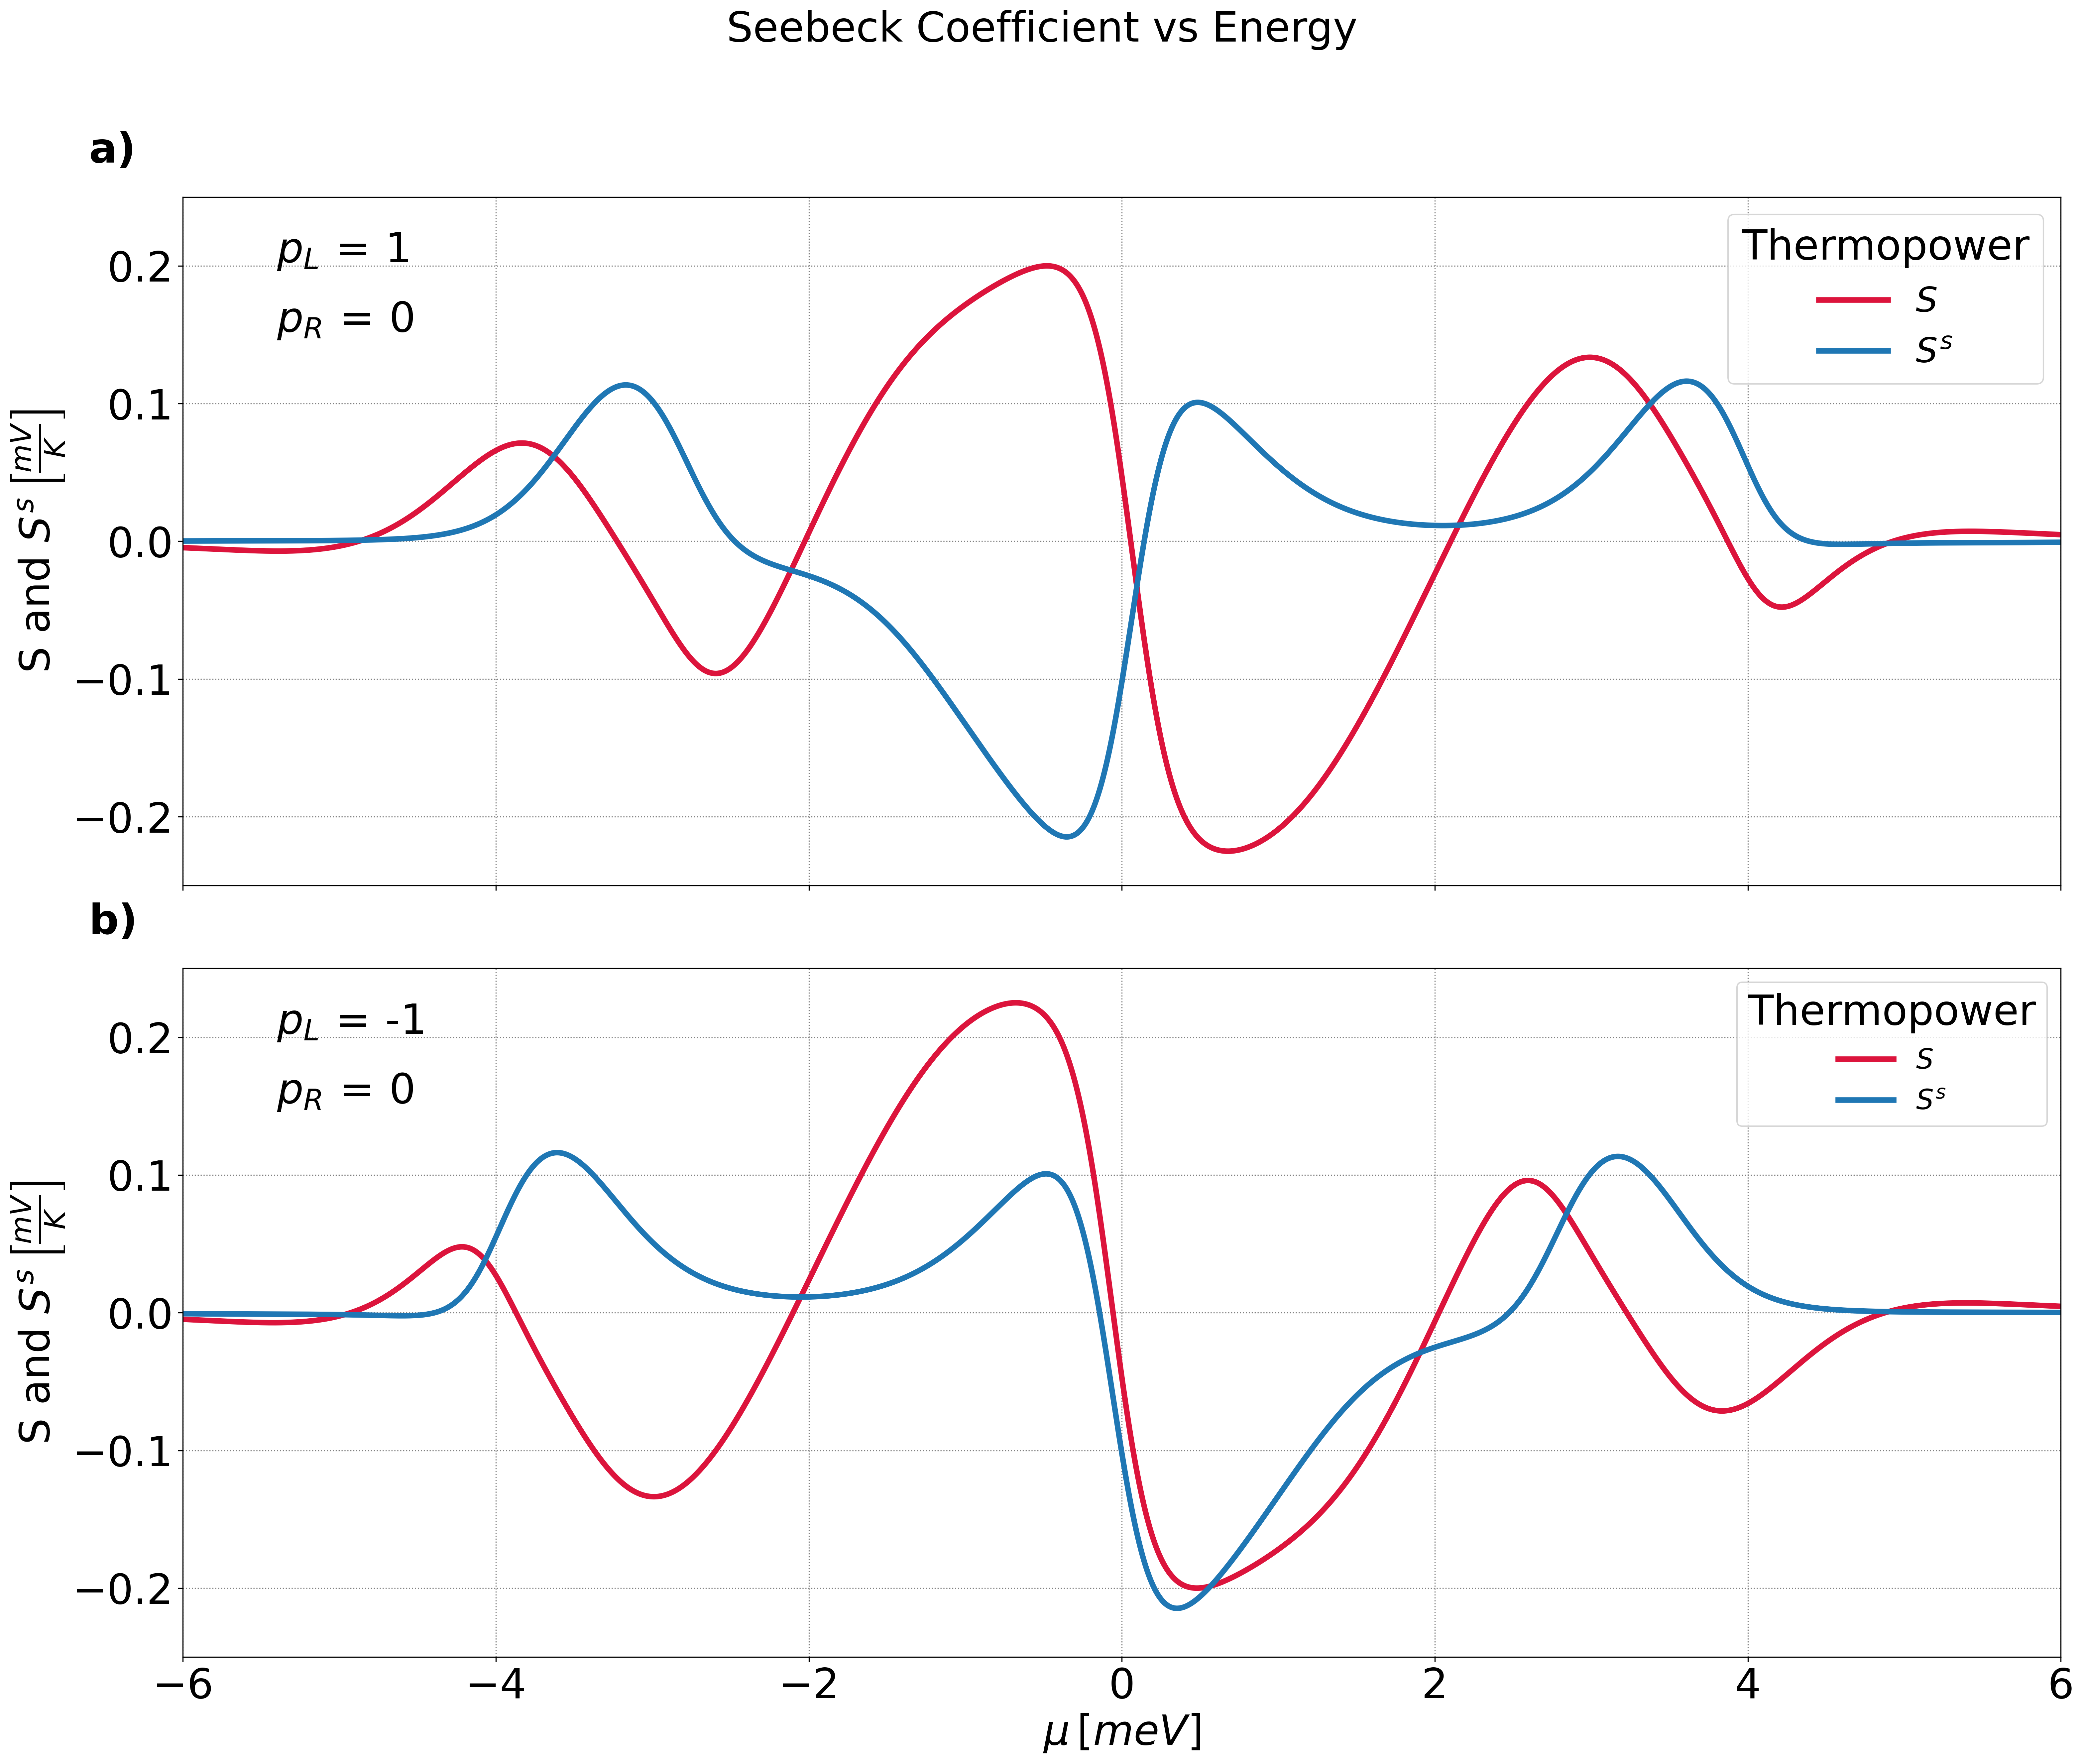

In [160]:
# Crear la figura y los ejes
fig = plt.figure(constrained_layout=True, figsize=(21, 18), dpi=300)

# these are matplotlib.patch.Patch properties
props = dict(boxstyle='round', facecolor='wheat', alpha=0)

# Set the grid for the subplots
gs = GridSpec(2, 1, figure=fig)

# Add the subplots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0])

ax1.grid(linestyle=':', color='grey')
ax1.plot(fermi_axis, -(1/2)*(seebeck_u_11 + seebeck_d_11), "#DC143C", label=r"$S$", linestyle="-", lw=4)
ax1.plot(fermi_axis, -(1/2)*(seebeck_u_11 - seebeck_d_11), "#1f77b4", label=r"$S^{s}$", linestyle="-", lw=4)
ax1.set_ylabel(r'S and $S^{s}\,\left[\frac{mV}{K} \right]$', fontsize=30)
ax1.text(0.05, 0.95, r"$p_{L}\,=\,$"+str(p_L_1), transform=ax1.transAxes, fontsize=30,
         verticalalignment='top', bbox=props)
ax1.text(0.05, 0.85, r"$p_{R}\,=\,$"+str(p_R_1), transform=ax1.transAxes, fontsize=30,
         verticalalignment='top', bbox=props)
ax1.legend(
    fontsize=25,
    title="Thermopower",
    title_fontsize=30,
    loc="upper right"
)
# Etiqueta a)
ax1.text(-0.05, 1.05, 'a)', transform=ax1.transAxes, fontsize=30, fontweight='bold')

ax2.grid(linestyle=':', color='grey')
ax2.plot(fermi_axis, -(1/2)*(seebeck_u_21 + seebeck_d_21), "#DC143C", label=r"$S$", linestyle="-", lw=4)
ax2.plot(fermi_axis, -(1/2)*(seebeck_u_21 - seebeck_d_21), "#1f77b4", label=r"$S^{s}$", linestyle="-", lw=4)
ax2.set_xlabel(r'$\mu\,[meV]$', fontsize=30)
ax2.set_ylabel(r'S and $S^{s}\,\left[\frac{mV}{K} \right]$', fontsize=30)
ax2.text(0.05, 0.95, r"$p_{L}\,=\,$"+str(p_L_2), transform=ax2.transAxes, fontsize=30,
         verticalalignment='top', bbox=props)
ax2.text(0.05, 0.85, r"$p_{R}\,=\,$"+str(p_R_2), transform=ax2.transAxes, fontsize=30,
         verticalalignment='top', bbox=props)
ax2.legend(
    fontsize=20,
    title="Thermopower",
    title_fontsize=30,
    loc="upper right"
)
# Etiqueta b)
ax2.text(-0.05, 1.05, 'b)', transform=ax2.transAxes, fontsize=30, fontweight='bold')

# Establecer límites para los subplots
ax1.set_xlim(-6, 6)
ax1.set_ylim(-0.25, 0.25)
ax2.set_xlim(-6, 6)
ax2.set_ylim(-0.25, 0.25)

# Ajustar el tamaño de las etiquetas de los ejes x e y
ax1.tick_params(axis='x', labelsize=30)
ax1.tick_params(axis='y', labelsize=30)
ax2.tick_params(axis='x', labelsize=30)
ax2.tick_params(axis='y', labelsize=30)

# Eliminar los números del eje x en el primer subplot
ax1.set_xticklabels([])

# Ajustar el diseño y mostrar los subplots
plt.suptitle("Seebeck Coefficient vs Energy", fontsize=30)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Guardar la imagen
#fig.savefig('final_thermopower_part1.jpg')

# COMPARISON

/home/franklin/miniconda3/envs/py37/lib/python3.7/site-packages/ipykernel_launcher.py:113: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.


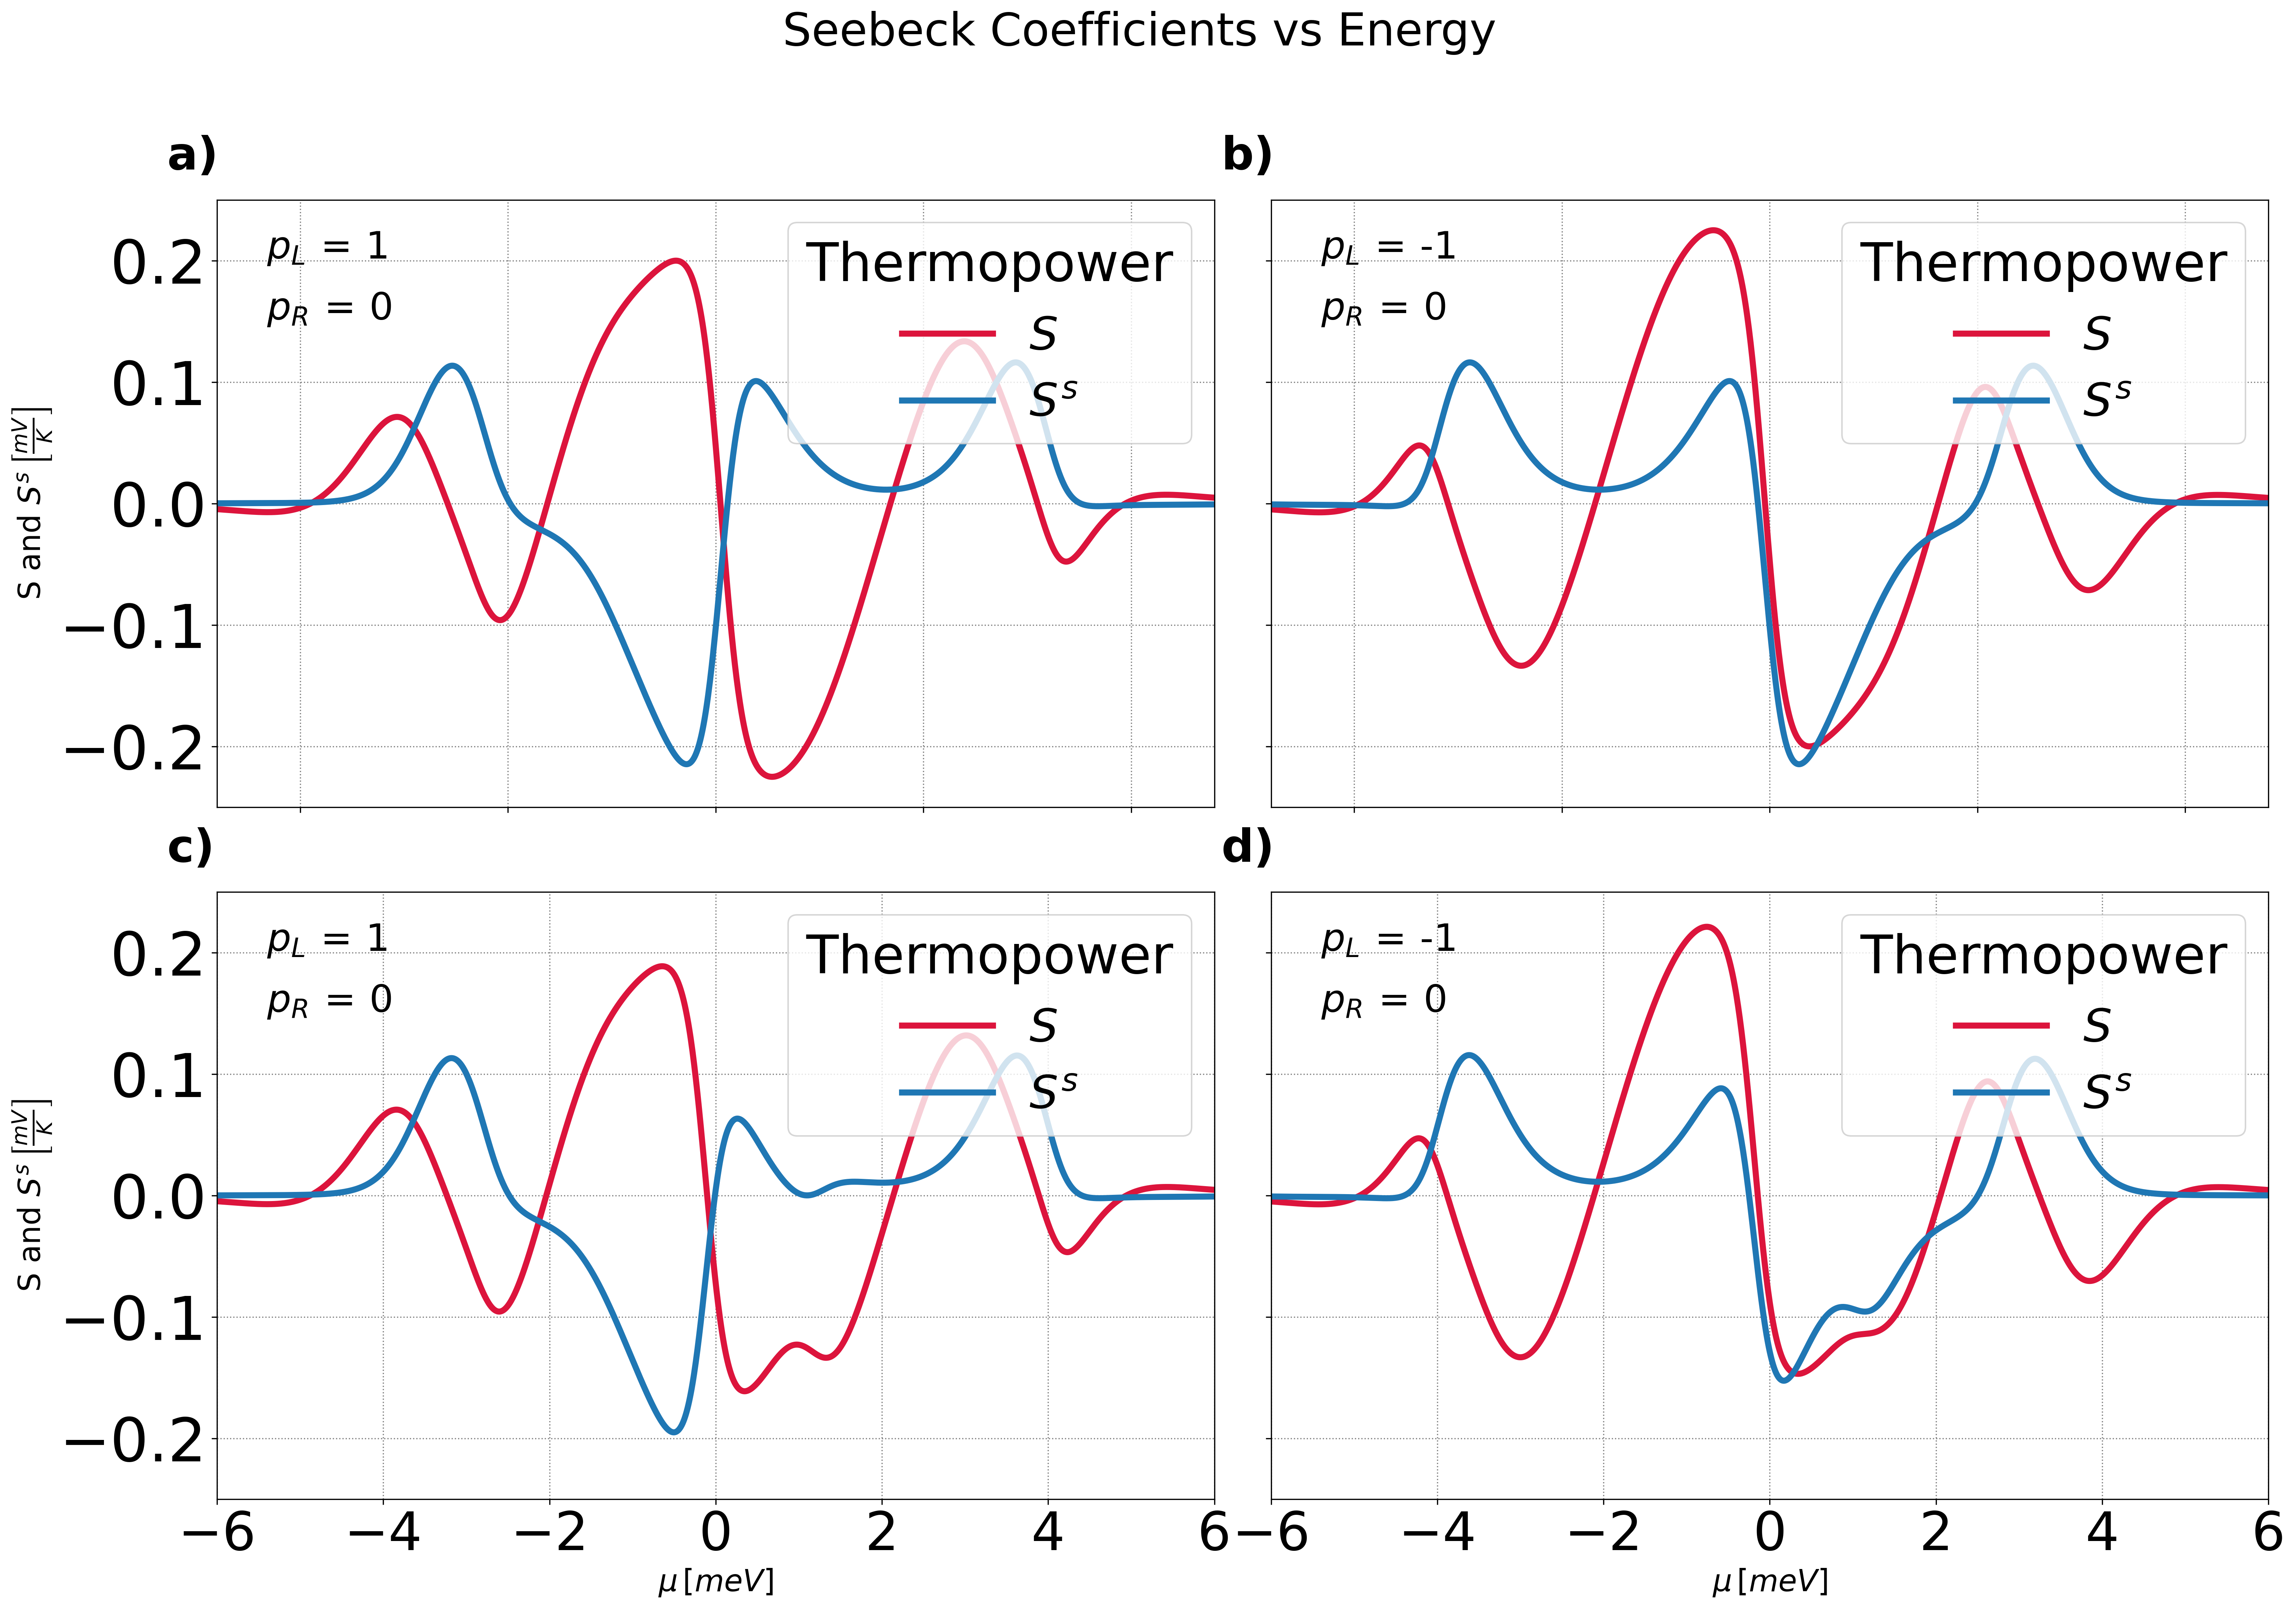

In [161]:
# Crear la figura y los ejes
fig = plt.figure(constrained_layout=True, figsize=(21, 15), dpi=300)

# these are matplotlib.patch.Patch properties
props = dict(boxstyle='round', facecolor='wheat', alpha=0)

# Set the grid for the subplots
gs = GridSpec(2, 2, figure=fig)

# Add the subplots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# Primer plot : UP - NM
ax1.grid(linestyle=':', color='grey')
ax1.plot(fermi_axis, -(1/2)*(seebeck_u_11 + seebeck_d_11), "#DC143C", label=r"$S$", linestyle="-", lw=4)
ax1.plot(fermi_axis, -(1/2)*(seebeck_u_11 - seebeck_d_11), "#1f77b4", label=r"$S^{s}$", linestyle="-", lw=4)
ax1.set_ylabel(r'S and $S^{s}\,\left[\frac{mV}{K} \right]$', fontsize=20)
ax1.text(0.05, 0.95, r"$p_{L}\,=\,$"+str(p_L_1), transform=ax1.transAxes, fontsize=25,
         verticalalignment='top', bbox=props)
ax1.text(0.05, 0.85, r"$p_{R}\,=\,$"+str(p_R_1), transform=ax1.transAxes, fontsize=25,
         verticalalignment='top', bbox=props)
ax1.legend(
    fontsize=30,
    title="Thermopower",
    title_fontsize=35,
    loc="upper right"
)
# Etiqueta a)
ax1.text(-0.05, 1.05, 'a)', transform=ax1.transAxes, fontsize=30, fontweight='bold')
ax1.set_xlim(-6, 6)
ax1.set_ylim(-0.25, 0.25)
ax1.tick_params(axis='x', labelsize=40)
ax1.tick_params(axis='y', labelsize=40)
ax1.set_xticklabels([])

# Segundo plot DOWN - NM
ax2.grid(linestyle=':', color='grey')
ax2.plot(fermi_axis, -(1/2)*(seebeck_u_21 + seebeck_d_21), "#DC143C", label=r"$S$", linestyle="-", lw=4)
ax2.plot(fermi_axis, -(1/2)*(seebeck_u_21 - seebeck_d_21), "#1f77b4", label=r"$S^{s}$", linestyle="-", lw=4)
#ax2.set_xlabel(r'$\mu\,[meV]$', fontsize=20)
#ax2.set_ylabel(r'S and $S^{s}\,\left[\frac{mV}{K} \right]$', fontsize=20)
ax2.text(0.05, 0.95, r"$p_{L}\,=\,$"+str(p_L_2), transform=ax2.transAxes, fontsize=25,
         verticalalignment='top', bbox=props)
ax2.text(0.05, 0.85, r"$p_{R}\,=\,$"+str(p_R_2), transform=ax2.transAxes, fontsize=25,
         verticalalignment='top', bbox=props)
ax2.legend(
    fontsize=30,
    title="Thermopower",
    title_fontsize=35,
    loc="upper right"
)
# Etiqueta b)
ax2.text(-0.05, 1.05, 'b)', transform=ax2.transAxes, fontsize=30, fontweight='bold')
ax2.set_xlim(-6, 6)
ax2.set_ylim(-0.25, 0.25)
ax2.tick_params(axis='x', labelsize=40)
ax2.tick_params(axis='y', labelsize=40)
ax2.set_xticklabels([])
ax2.set_yticklabels([])

# Tercer plot : UP - NM
ax3.grid(linestyle=':', color='grey')
ax3.plot(fermi_axis, -(1/2)*(seebeck_u_1 + seebeck_d_1), "#DC143C", label=r"$S$", linestyle="-", lw=4)
ax3.plot(fermi_axis, -(1/2)*(seebeck_u_1 - seebeck_d_1), "#1f77b4", label=r"$S^{s}$", linestyle="-", lw=4)
ax3.set_ylabel(r'S and $S^{s}\,\left[\frac{mV}{K} \right]$', fontsize=20)
ax3.set_xlabel(r'$\mu\,[meV]$', fontsize=20)
ax3.text(0.05, 0.95, r"$p_{L}\,=\,$"+str(p_L_1), transform=ax3.transAxes, fontsize=25,
         verticalalignment='top', bbox=props)
ax3.text(0.05, 0.85, r"$p_{R}\,=\,$"+str(p_R_1), transform=ax3.transAxes, fontsize=25,
         verticalalignment='top', bbox=props)
ax3.legend(
    fontsize=30,
    title="Thermopower",
    title_fontsize=35,
    loc="upper right"
)
# Etiqueta c) 
ax3.text(-0.05, 1.05, 'c)', transform=ax3.transAxes, fontsize=30, fontweight='bold')
ax3.set_xlim(-6, 6)
ax3.set_ylim(-0.25, 0.25)
ax3.tick_params(axis='x', labelsize=35)
ax3.tick_params(axis='y', labelsize=40)

# Cuarto plot : DOWN - NM
ax4.grid(linestyle=':', color='grey')
ax4.plot(fermi_axis, -(1/2)*(seebeck_u_2 + seebeck_d_2), "#DC143C", label=r"$S$", linestyle="-", lw=4)
ax4.plot(fermi_axis, -(1/2)*(seebeck_u_2 - seebeck_d_2), "#1f77b4", label=r"$S^{s}$", linestyle="-", lw=4)
ax4.set_xlabel(r'$\mu\,[meV]$', fontsize=20)
#ax4.set_ylabel(r'S and $S^{s}\,\left[\frac{mV}{K} \right]$', fontsize=20)
ax4.text(0.05, 0.95, r"$p_{L}\,=\,$"+str(p_L_2), transform=ax4.transAxes, fontsize=25,
         verticalalignment='top', bbox=props)
ax4.text(0.05, 0.85, r"$p_{R}\,=\,$"+str(p_R_2), transform=ax4.transAxes, fontsize=25,
         verticalalignment='top', bbox=props)
ax4.legend(
    fontsize=30,
    title="Thermopower",
    title_fontsize=35,
    loc="upper right"
)
# Etiqueta d)
ax4.text(-0.05, 1.05, 'd)', transform=ax4.transAxes, fontsize=30, fontweight='bold')
ax4.set_xlim(-6, 6)
ax4.set_ylim(-0.25, 0.25)
ax4.tick_params(axis='x', labelsize=35)
ax4.tick_params(axis='y', labelsize=40)
ax4.set_yticklabels([])

# Ajustar el diseño y mostrar los subplots
plt.suptitle("Seebeck Coefficients vs Energy", fontsize=30)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Guardar la imagen
fig.savefig('final_combined_thermopower.jpg')


/home/franklin/miniconda3/envs/py37/lib/python3.7/site-packages/ipykernel_launcher.py:113: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.


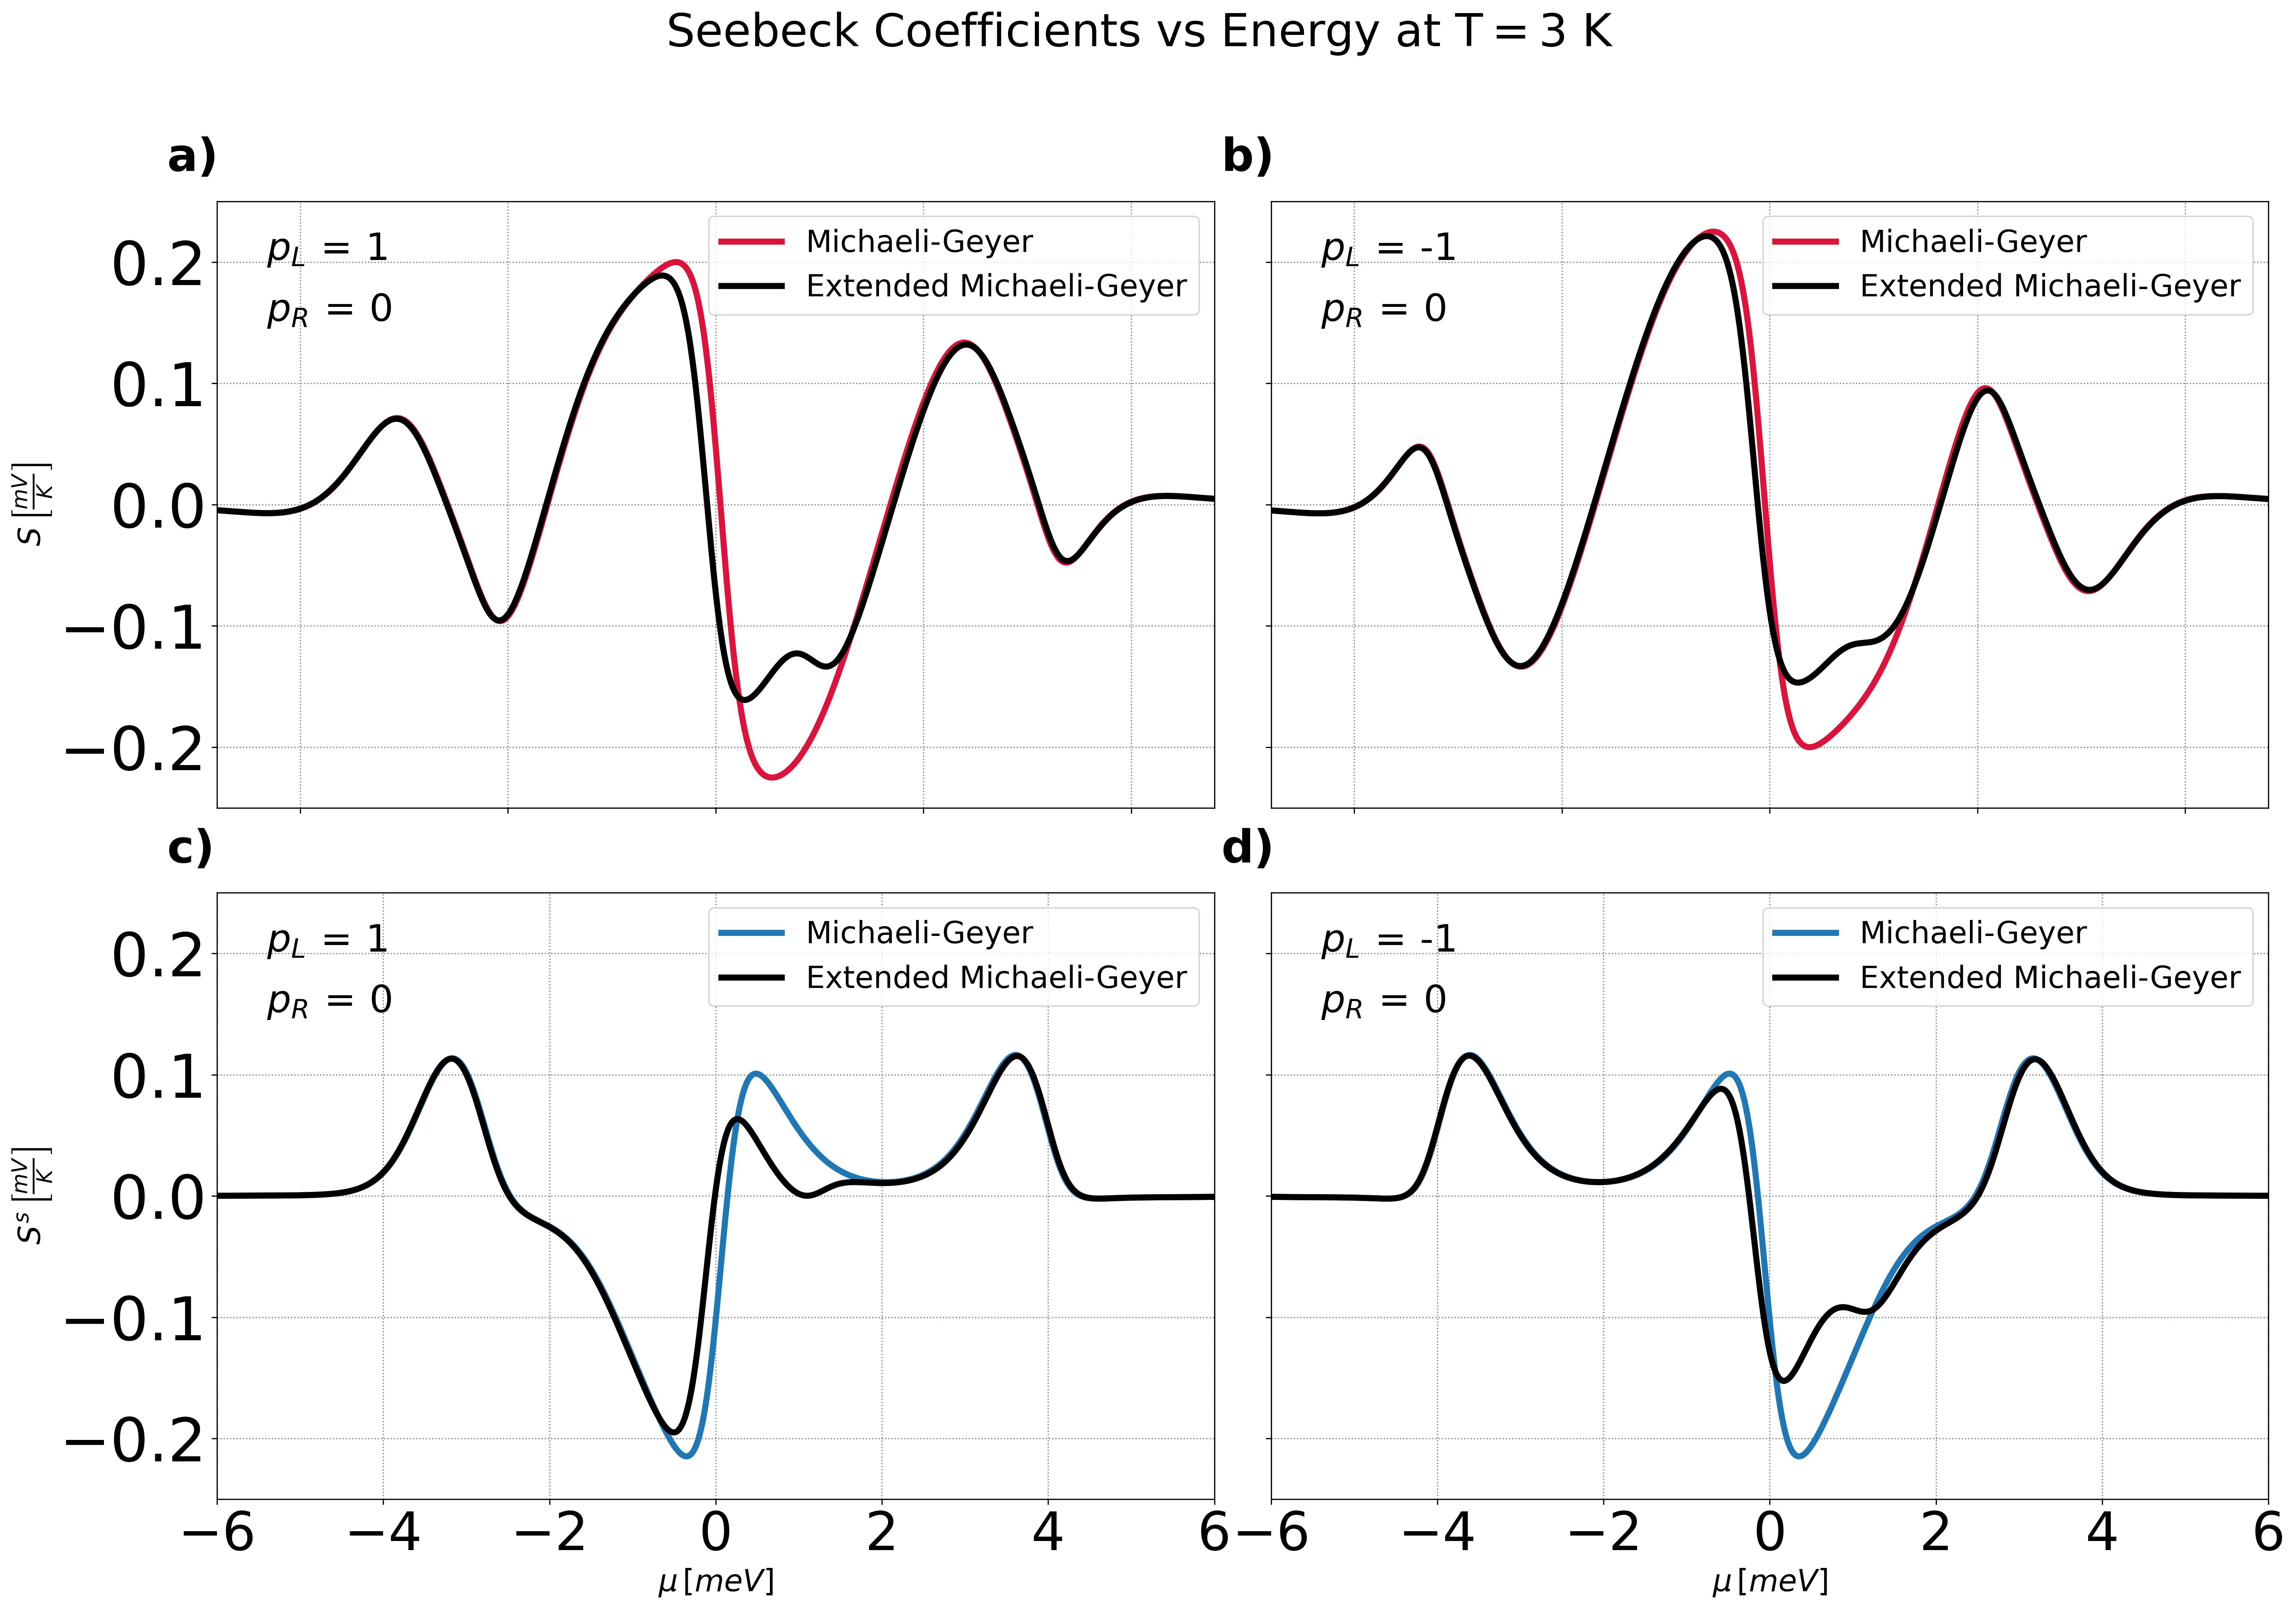

In [162]:
# Crear la figura y los ejes
fig = plt.figure(constrained_layout=True, figsize=(21, 15), dpi=300)

# these are matplotlib.patch.Patch properties
props = dict(boxstyle='round', facecolor='wheat', alpha=0)

# Set the grid for the subplots
gs = GridSpec(2, 2, figure=fig)

# Add the subplots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# Primer plot : UP - NM
ax1.grid(linestyle=':', color='grey')
ax1.plot(fermi_axis, -(1/2)*(seebeck_u_11 + seebeck_d_11), "#DC143C", label=r"Michaeli-Geyer", linestyle="-", lw=4)
ax1.plot(fermi_axis, -(1/2)*(seebeck_u_1 + seebeck_d_1), "black", label=r"Extended Michaeli-Geyer", linestyle="-", lw=4)
ax1.set_ylabel(r'$S \,\left[\frac{mV}{K} \right]$', fontsize=20)
ax1.text(0.05, 0.95, r"$p_{L}\,=\,$"+str(p_L_1), transform=ax1.transAxes, fontsize=25,
         verticalalignment='top', bbox=props)
ax1.text(0.05, 0.85, r"$p_{R}\,=\,$"+str(p_R_1), transform=ax1.transAxes, fontsize=25,
         verticalalignment='top', bbox=props)
ax1.legend(
    fontsize=20,
    #title="Thermopower",
    title_fontsize=25,
    loc="upper right"
)
# Etiqueta a)
ax1.text(-0.05, 1.05, 'a)', transform=ax1.transAxes, fontsize=30, fontweight='bold')
ax1.set_xlim(-6, 6)
ax1.set_ylim(-0.25, 0.25)
ax1.tick_params(axis='x', labelsize=40)
ax1.tick_params(axis='y', labelsize=40)
ax1.set_xticklabels([])

# Segundo plot DOWN - NM
ax2.grid(linestyle=':', color='grey')
ax2.plot(fermi_axis, -(1/2)*(seebeck_u_21 + seebeck_d_21), "#DC143C", label=r"Michaeli-Geyer", linestyle="-", lw=4)
ax2.plot(fermi_axis, -(1/2)*(seebeck_u_2 + seebeck_d_2), "black", label=r"Extended Michaeli-Geyer", linestyle="-", lw=4)
#ax2.set_xlabel(r'$\mu\,[meV]$', fontsize=20)
#ax2.set_ylabel(r'S and $S^{s}\,\left[\frac{mV}{K} \right]$', fontsize=20)
ax2.text(0.05, 0.95, r"$p_{L}\,=\,$"+str(p_L_2), transform=ax2.transAxes, fontsize=25,
         verticalalignment='top', bbox=props)
ax2.text(0.05, 0.85, r"$p_{R}\,=\,$"+str(p_R_2), transform=ax2.transAxes, fontsize=25,
         verticalalignment='top', bbox=props)
ax2.legend(
    fontsize=20,
    #title="Thermopower",
    title_fontsize=25,
    loc="upper right"
)
# Etiqueta b)
ax2.text(-0.05, 1.05, 'b)', transform=ax2.transAxes, fontsize=30, fontweight='bold')
ax2.set_xlim(-6, 6)
ax2.set_ylim(-0.25, 0.25)
ax2.tick_params(axis='x', labelsize=40)
ax2.tick_params(axis='y', labelsize=40)
ax2.set_xticklabels([])
ax2.set_yticklabels([])

# Tercer plot : UP - NM
ax3.grid(linestyle=':', color='grey')
ax3.plot(fermi_axis, -(1/2)*(seebeck_u_11 - seebeck_d_11), "#1f77b4", label=r"Michaeli-Geyer", linestyle="-", lw=4)
ax3.plot(fermi_axis, -(1/2)*(seebeck_u_1 - seebeck_d_1), "black", label=r"Extended Michaeli-Geyer", linestyle="-", lw=4)
ax3.set_ylabel(r'$S^{s}\,\left[\frac{mV}{K} \right]$', fontsize=20)
ax3.set_xlabel(r'$\mu\,[meV]$', fontsize=20)
ax3.text(0.05, 0.95, r"$p_{L}\,=\,$"+str(p_L_1), transform=ax3.transAxes, fontsize=25,
         verticalalignment='top', bbox=props)
ax3.text(0.05, 0.85, r"$p_{R}\,=\,$"+str(p_R_1), transform=ax3.transAxes, fontsize=25,
         verticalalignment='top', bbox=props)
ax3.legend(
    fontsize=20,
    #title="Thermopower",
    title_fontsize=25,
    loc="upper right"
)
# Etiqueta c) 
ax3.text(-0.05, 1.05, 'c)', transform=ax3.transAxes, fontsize=30, fontweight='bold')
ax3.set_xlim(-6, 6)
ax3.set_ylim(-0.25, 0.25)
ax3.tick_params(axis='x', labelsize=35)
ax3.tick_params(axis='y', labelsize=40)

# Cuarto plot : DOWN - NM
ax4.grid(linestyle=':', color='grey')
ax4.plot(fermi_axis, -(1/2)*(seebeck_u_21 - seebeck_d_21), "#1f77b4", label=r"Michaeli-Geyer", linestyle="-", lw=4)
ax4.plot(fermi_axis, -(1/2)*(seebeck_u_2 - seebeck_d_2), "black", label=r"Extended Michaeli-Geyer", linestyle="-", lw=4)
ax4.set_xlabel(r'$\mu\,[meV]$', fontsize=20)
#ax4.set_ylabel(r'S and $S^{s}\,\left[\frac{mV}{K} \right]$', fontsize=20)
ax4.text(0.05, 0.95, r"$p_{L}\,=\,$"+str(p_L_2), transform=ax4.transAxes, fontsize=25,
         verticalalignment='top', bbox=props)
ax4.text(0.05, 0.85, r"$p_{R}\,=\,$"+str(p_R_2), transform=ax4.transAxes, fontsize=25,
         verticalalignment='top', bbox=props)
ax4.legend(
    fontsize=20,
    #title="Thermopower",
    title_fontsize=25,
    loc="upper right"
)
# Etiqueta d)
ax4.text(-0.05, 1.05, 'd)', transform=ax4.transAxes, fontsize=30, fontweight='bold')
ax4.set_xlim(-6, 6)
ax4.set_ylim(-0.25, 0.25)
ax4.tick_params(axis='x', labelsize=35)
ax4.tick_params(axis='y', labelsize=40)
ax4.set_yticklabels([])

# Ajustar el diseño y mostrar los subplots
plt.suptitle(f"Seebeck Coefficients vs Energy at T$=${temperature} K", fontsize=30)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Guardar la imagen
fig.savefig('thermopower_efficiency_explanation_0.jpg')


In [163]:
inicio=0.8
fin = 1.2

#Find the positions/locations in the arange for the interval 0.9< mu <1.1
indices = np.where((fermi_axis>=inicio) & (fermi_axis<=fin))[0]
#print(f"The indices for the desired interval are: {indices}")

In [164]:
print(f"For the coupling regime $t/\gamma$ = {t/gamma} at T = {temperature} K")
print(f"The interval in the Fermi energy values : [{fermi_axis[indices[0]]},{fermi_axis[indices[-1]]}]")
print(f"The Spin Thermopower in the Michaeli-Geyer model in L={p_L_1} are: {-(1/2)*(seebeck_u_11[indices[0]:indices[-1]] - seebeck_d_11[indices[0]:indices[-1]])}")
print(f"The Spin Thermopower in the Extended Michaeli-Geyer model L={p_L_1} are: {-(1/2)*(seebeck_u_1[indices[0]:indices[-1]] - seebeck_d_1[indices[0]:indices[-1]])}")
print(f"The Spin Thermopower in the Michaeli-Geyer model in L={p_L_2} are: {-(1/2)*(seebeck_u_21[indices[0]:indices[-1]] - seebeck_d_21[indices[0]:indices[-1]])}")
print(f"The Spin Thermopower in the Extended Michaeli-Geyer model L={p_L_2} are: {-(1/2)*(seebeck_u_2[indices[0]:indices[-1]] - seebeck_d_2[indices[0]:indices[-1]])}")

For the coupling regime $t/\gamma$ = 7.0 at T = 3 K
The interval in the Fermi energy values : [0.8099999999998548,1.1999999999998465]
The Spin Thermopower in the Michaeli-Geyer model in L=1 are: [0.07465252 0.07353877 0.0724259  0.07131483 0.07020643 0.0691015
 0.06800082 0.06690511 0.06581504 0.06473125 0.06365433 0.06258485
 0.06152334 0.06047027 0.05942613 0.05839132 0.05736626 0.05635132
 0.05534684 0.05435314 0.05337053 0.05239927 0.05143962 0.05049181
 0.04955604 0.04863252 0.0477214  0.04682285 0.045937   0.04506397
 0.04420387 0.04335679 0.0425228  0.04170197 0.04089433 0.04009994
 0.0393188  0.03855094 0.03779635]
The Spin Thermopower in the Extended Michaeli-Geyer model L=1 are: [0.0128599  0.01205483 0.01127071 0.01050812 0.00976766 0.00904997
 0.00835565 0.00768536 0.00703974 0.00641946 0.00582517 0.00525755
 0.00471725 0.00420491 0.00372118 0.00326666 0.00284195 0.00244758
 0.00208407 0.00175187 0.00145137 0.00118291 0.00094672 0.00074298
 0.00057175 0.00043302 0.00032665 

# Wire-like dimers

In [165]:
#More Parameters
temperature = 3 #Kelvin
print("T is:", temperature,"Kelvin")

fermi_axis = np.arange(-6, 6 + 0.01, 0.01) #meV
print("Fermi Energy axis is", fermi_axis,"meV")

T is: 3 Kelvin
Fermi Energy axis is [-6.   -5.99 -5.98 ...  5.98  5.99  6.  ] meV


In [166]:
L = 0
#Intradot Hopping parameter:
om = k*gamma #meV

#Renormalized site energies array:
e_ren_1_u = np.array([e_01,e_11, om])
e_ren_1_d = np.array([e_01,e_11, om])

e_ren_2_u = np.array([e_02, e_12, om])
e_ren_2_d = np.array([e_02, e_12, om])


site_energies = np.array([e_ren_1_u, e_ren_1_d , e_ren_2_u , e_ren_2_d], dtype = complex)

Hamiltonian = np.array([[ lam_2*L*B, -(1j)*lam_2*L*B,-t,0],[(1j)*lam_2*L*B, -lam_2*L*B, 0,-t],[-t,0, lam_2*L*B, -(1j)*lam_2*L*B],\
                        [0,-t, (1j)*lam_2*L*B, -lam_2*L*B]], dtype = complex)

print(Hamiltonian)

[[-0. +0.j -0. +0.j -3.5+0.j  0. +0.j]
 [-0. +0.j  0. +0.j  0. +0.j -3.5+0.j]
 [-3.5+0.j  0. +0.j -0. +0.j -0. +0.j]
 [ 0. +0.j -3.5+0.j -0. +0.j  0. +0.j]]


In [167]:
#POLARIZATION UP-UP
p_L_1 = 1
p_R_1 = 0

#Transmission axis

transmission_u_1 = fy.Transmission(energy_axis,gamma, Hamiltonian, site_energies, p_L_1, p_R_1)[0]
transmission_d_1 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_1, p_R_1)[1]

#Thermopower
seebeck_1 = th.S(fermi_axis, temperature, energy_axis, p_L_1, p_R_1, gamma, Hamiltonian, site_energies)
seebeck_u_1 = th.S_up(fermi_axis, temperature, energy_axis, p_L_1, p_R_1, gamma, Hamiltonian, site_energies)
seebeck_d_1 = th.S_down(fermi_axis, temperature, energy_axis, p_L_1, p_R_1, gamma, Hamiltonian, site_energies)

In [168]:
#POLARIZATION UP-DOWN
p_L_2 = -1
p_R_2 = 0

#Transmission axis

transmission_u_2 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_2, p_R_2)[0]
transmission_d_2 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_2, p_R_2)[1]

#Thermopower
seebeck_2 = th.S(fermi_axis, temperature, energy_axis, p_L_2, p_R_2, gamma, Hamiltonian, site_energies)
seebeck_u_2 = th.S_up(fermi_axis, temperature, energy_axis, p_L_2, p_R_2, gamma, Hamiltonian, site_energies)
seebeck_d_2 = th.S_down(fermi_axis, temperature, energy_axis, p_L_2, p_R_2, gamma, Hamiltonian, site_energies)

In [169]:
# Aplicar cutoff suave a seebeck_1, seebeck_u_1 y seebeck_d_1
seebeck_1 = sigmoid_cutoff(seebeck_1, fermi_axis)
seebeck_u_1 = sigmoid_cutoff(seebeck_u_1, fermi_axis)
seebeck_d_1 = sigmoid_cutoff(seebeck_d_1, fermi_axis)

# Aplicar cutoff suave a seebeck_2, seebeck_u_2 y seebeck_d_2
seebeck_2 = sigmoid_cutoff(seebeck_2, fermi_axis)
seebeck_u_2 = sigmoid_cutoff(seebeck_u_2, fermi_axis)
seebeck_d_2 = sigmoid_cutoff(seebeck_d_2, fermi_axis)


/home/franklin/miniconda3/envs/py37/lib/python3.7/site-packages/ipykernel_launcher.py:66: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.


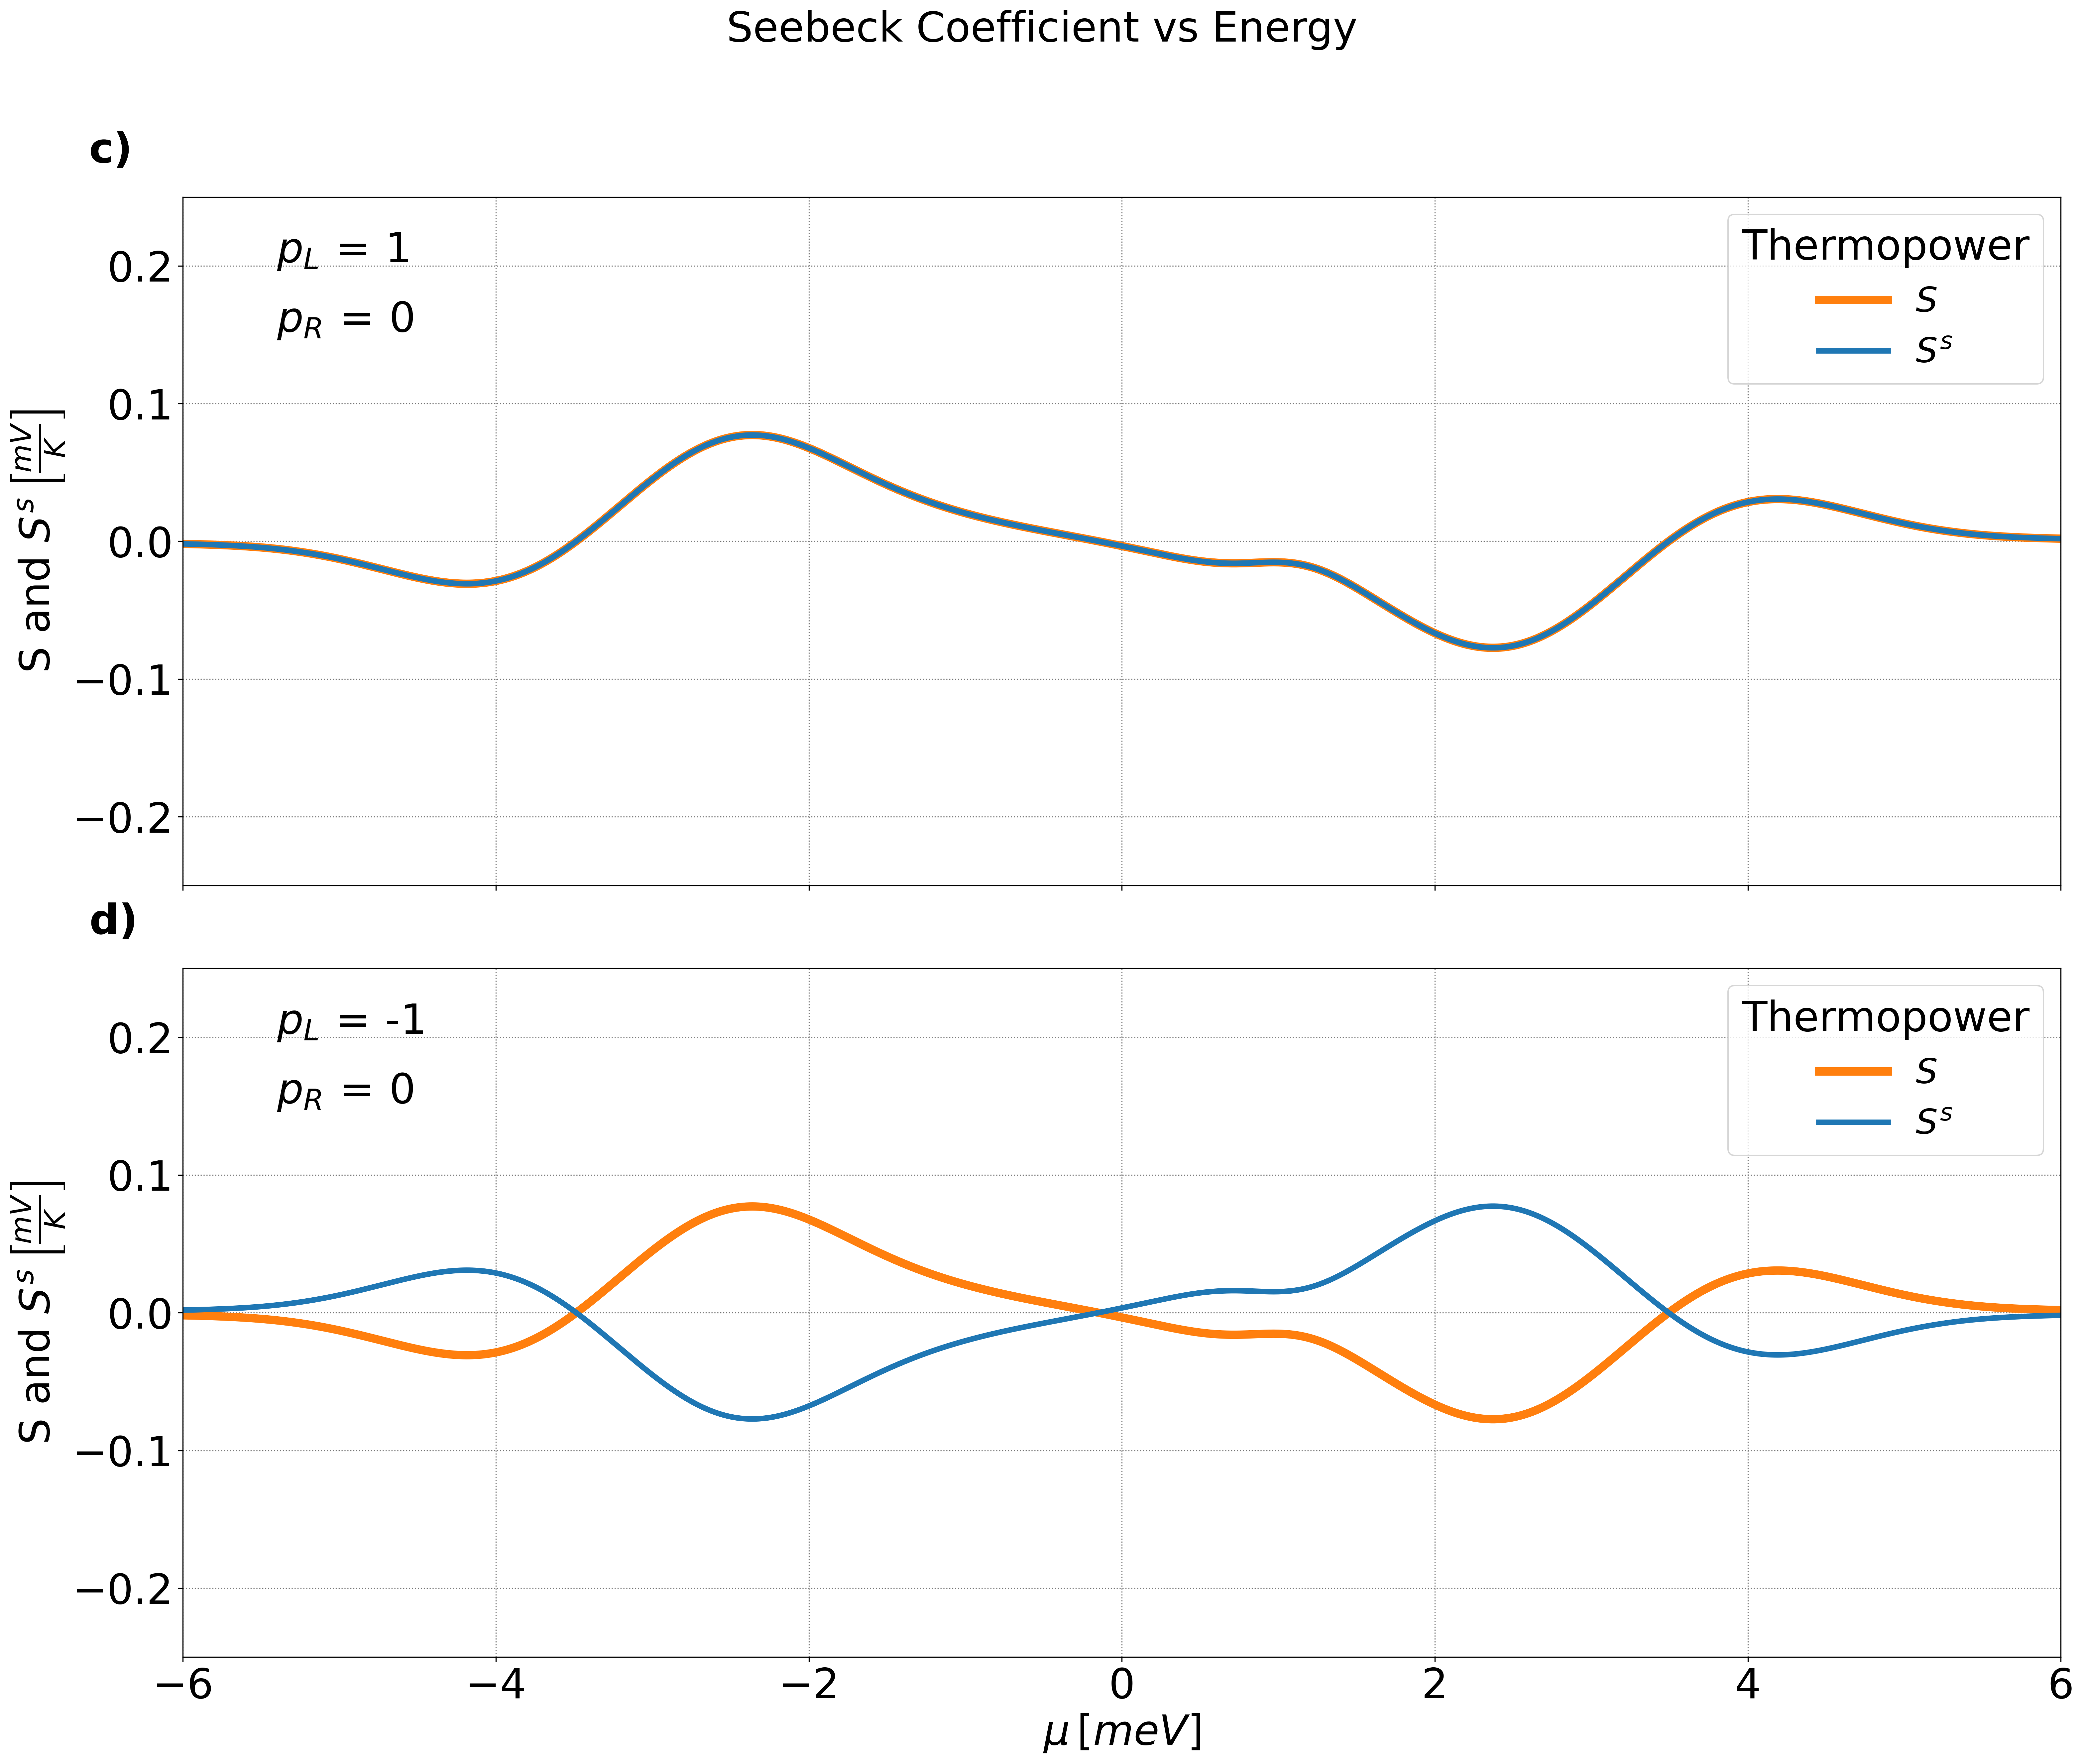

In [170]:
# Crear la figura y los ejes
fig = plt.figure(constrained_layout=True, figsize=(21, 18), dpi=300)

# these are matplotlib.patch.Patch properties
props = dict(boxstyle='round', facecolor='wheat', alpha=0)

# Set the grid for the subplots
gs = GridSpec(2, 1, figure=fig)

# Add the subplots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0])

ax1.grid(linestyle=':', color='grey')
ax1.plot(fermi_axis, -(1/2)*(seebeck_u_1 + seebeck_d_1), "#ff7f0e", label=r"$S$", linestyle="-", lw=6)
ax1.plot(fermi_axis, -(1/2)*(seebeck_u_1 - seebeck_d_1), "#1f77b4", label=r"$S^{s}$", linestyle="-", lw=4)
ax1.set_ylabel(r'S and $S^{s}\,\left[\frac{mV}{K} \right]$', fontsize=30)
ax1.text(0.05, 0.95, r"$p_{L}\,=\,$"+str(p_L_1), transform=ax1.transAxes, fontsize=30,
         verticalalignment='top', bbox=props)
ax1.text(0.05, 0.85, r"$p_{R}\,=\,$"+str(p_R_1), transform=ax1.transAxes, fontsize=30,
         verticalalignment='top', bbox=props)
ax1.legend(
    fontsize=25,
    title="Thermopower",
    title_fontsize=30,
    loc="upper right"
)
# Etiqueta a)
ax1.text(-0.05, 1.05, 'c)', transform=ax1.transAxes, fontsize=30, fontweight='bold')

ax2.grid(linestyle=':', color='grey')
ax2.plot(fermi_axis, -(1/2)*(seebeck_u_2 + seebeck_d_2), "#ff7f0e", label=r"$S$", linestyle="-", lw=6)
ax2.plot(fermi_axis, -(1/2)*(seebeck_u_2 - seebeck_d_2), "#1f77b4", label=r"$S^{s}$", linestyle="-", lw=4)
ax2.set_xlabel(r'$\mu\,[meV]$', fontsize=30)
ax2.set_ylabel(r'S and $S^{s}\,\left[\frac{mV}{K} \right]$', fontsize=30)
ax2.text(0.05, 0.95, r"$p_{L}\,=\,$"+str(p_L_2), transform=ax2.transAxes, fontsize=30,
         verticalalignment='top', bbox=props)
ax2.text(0.05, 0.85, r"$p_{R}\,=\,$"+str(p_R_2), transform=ax2.transAxes, fontsize=30,
         verticalalignment='top', bbox=props)
ax2.legend(
    fontsize=25,
    title="Thermopower",
    title_fontsize=30,
    loc="upper right"
)
# Etiqueta b)
ax2.text(-0.05, 1.05, 'd)', transform=ax2.transAxes, fontsize=30, fontweight='bold')

# Establecer límites para los subplots
ax1.set_xlim(-6, 6)
ax1.set_ylim(-0.25, 0.25)
ax2.set_xlim(-6, 6)
ax2.set_ylim(-0.25, 0.25)

# Ajustar el tamaño de las etiquetas de los ejes x e y
ax1.tick_params(axis='x', labelsize=30)
ax1.tick_params(axis='y', labelsize=30)
ax2.tick_params(axis='x', labelsize=30)
ax2.tick_params(axis='y', labelsize=30)

# Eliminar los números del eje x en el primer subplot
ax1.set_xticklabels([])

# Ajustar el diseño y mostrar los subplots
plt.suptitle("Seebeck Coefficient vs Energy", fontsize=30)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Guardar la imagen
#fig.savefig('final_thermopower_part2.jpg')

In [171]:
#More Parameters
temperature = 3 #Kelvin
print("T is:", temperature,"Kelvin")

fermi_axis = np.arange(-6, 6 + 0.01, 0.01) #meV
print("Fermi Energy axis is", fermi_axis,"meV")

T is: 3 Kelvin
Fermi Energy axis is [-6.   -5.99 -5.98 ...  5.98  5.99  6.  ] meV


In [172]:
L = 0
#Intradot Hopping parameter:
om = 0*gamma #meV

#Renormalized site energies array:
e_ren_1_u1 = np.array([e_01,e_11, om])
e_ren_1_d1 = np.array([e_01,e_11, om])

e_ren_2_u1 = np.array([e_02, e_12, om])
e_ren_2_d1 = np.array([e_02, e_12, om])


site_energies1 = np.array([e_ren_1_u1, e_ren_1_d1 , e_ren_2_u1 , e_ren_2_d1], dtype = complex)

Hamiltonian = np.array([[ lam_2*L*B, -(1j)*lam_2*L*B,-t,0],[(1j)*lam_2*L*B, -lam_2*L*B, 0,-t],[-t,0, lam_2*L*B, -(1j)*lam_2*L*B],\
                        [0,-t, (1j)*lam_2*L*B, -lam_2*L*B]], dtype = complex)

print(Hamiltonian)

[[-0. +0.j -0. +0.j -3.5+0.j  0. +0.j]
 [-0. +0.j  0. +0.j  0. +0.j -3.5+0.j]
 [-3.5+0.j  0. +0.j -0. +0.j -0. +0.j]
 [ 0. +0.j -3.5+0.j -0. +0.j  0. +0.j]]


In [173]:
#POLARIZATION UP-UP
p_L_1 = 1
p_R_1 = 0

#Transmission axis

transmission_u_11 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies1, p_L_1, p_R_1)[0]
transmission_d_11 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies1, p_L_1, p_R_1)[1]

#Thermopower
seebeck_11 = th.S(fermi_axis, temperature, energy_axis, p_L_1, p_R_1, gamma, Hamiltonian, site_energies1)
seebeck_u_11 = th.S_up(fermi_axis, temperature, energy_axis, p_L_1, p_R_1, gamma, Hamiltonian, site_energies1)
seebeck_d_11 = th.S_down(fermi_axis, temperature, energy_axis, p_L_1, p_R_1, gamma, Hamiltonian, site_energies1)

In [174]:
#POLARIZATION UP-DOWN
p_L_2 = -1
p_R_2 = 0

#Transmission axis

transmission_u_21 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies1, p_L_2, p_R_2)[0]
transmission_d_21 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies1, p_L_2, p_R_2)[1]

#Thermopower
seebeck_21 = th.S(fermi_axis, temperature, energy_axis, p_L_2, p_R_2, gamma, Hamiltonian, site_energies1)
seebeck_u_21 = th.S_up(fermi_axis, temperature, energy_axis, p_L_2, p_R_2, gamma, Hamiltonian, site_energies1)
seebeck_d_21 = th.S_down(fermi_axis, temperature, energy_axis, p_L_2, p_R_2, gamma, Hamiltonian, site_energies1)

In [175]:
# Aplicar cutoff suave a seebeck_1, seebeck_u_1 y seebeck_d_1
seebeck_11 = sigmoid_cutoff(seebeck_11, fermi_axis)
seebeck_u_11 = sigmoid_cutoff(seebeck_u_11, fermi_axis)
seebeck_d_11 = sigmoid_cutoff(seebeck_d_11, fermi_axis)

# Aplicar cutoff suave a seebeck_2, seebeck_u_2 y seebeck_d_2
seebeck_21 = sigmoid_cutoff(seebeck_21, fermi_axis)
seebeck_u_21 = sigmoid_cutoff(seebeck_u_21, fermi_axis)
seebeck_d_21 = sigmoid_cutoff(seebeck_d_21, fermi_axis)


/home/franklin/miniconda3/envs/py37/lib/python3.7/site-packages/ipykernel_launcher.py:66: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.


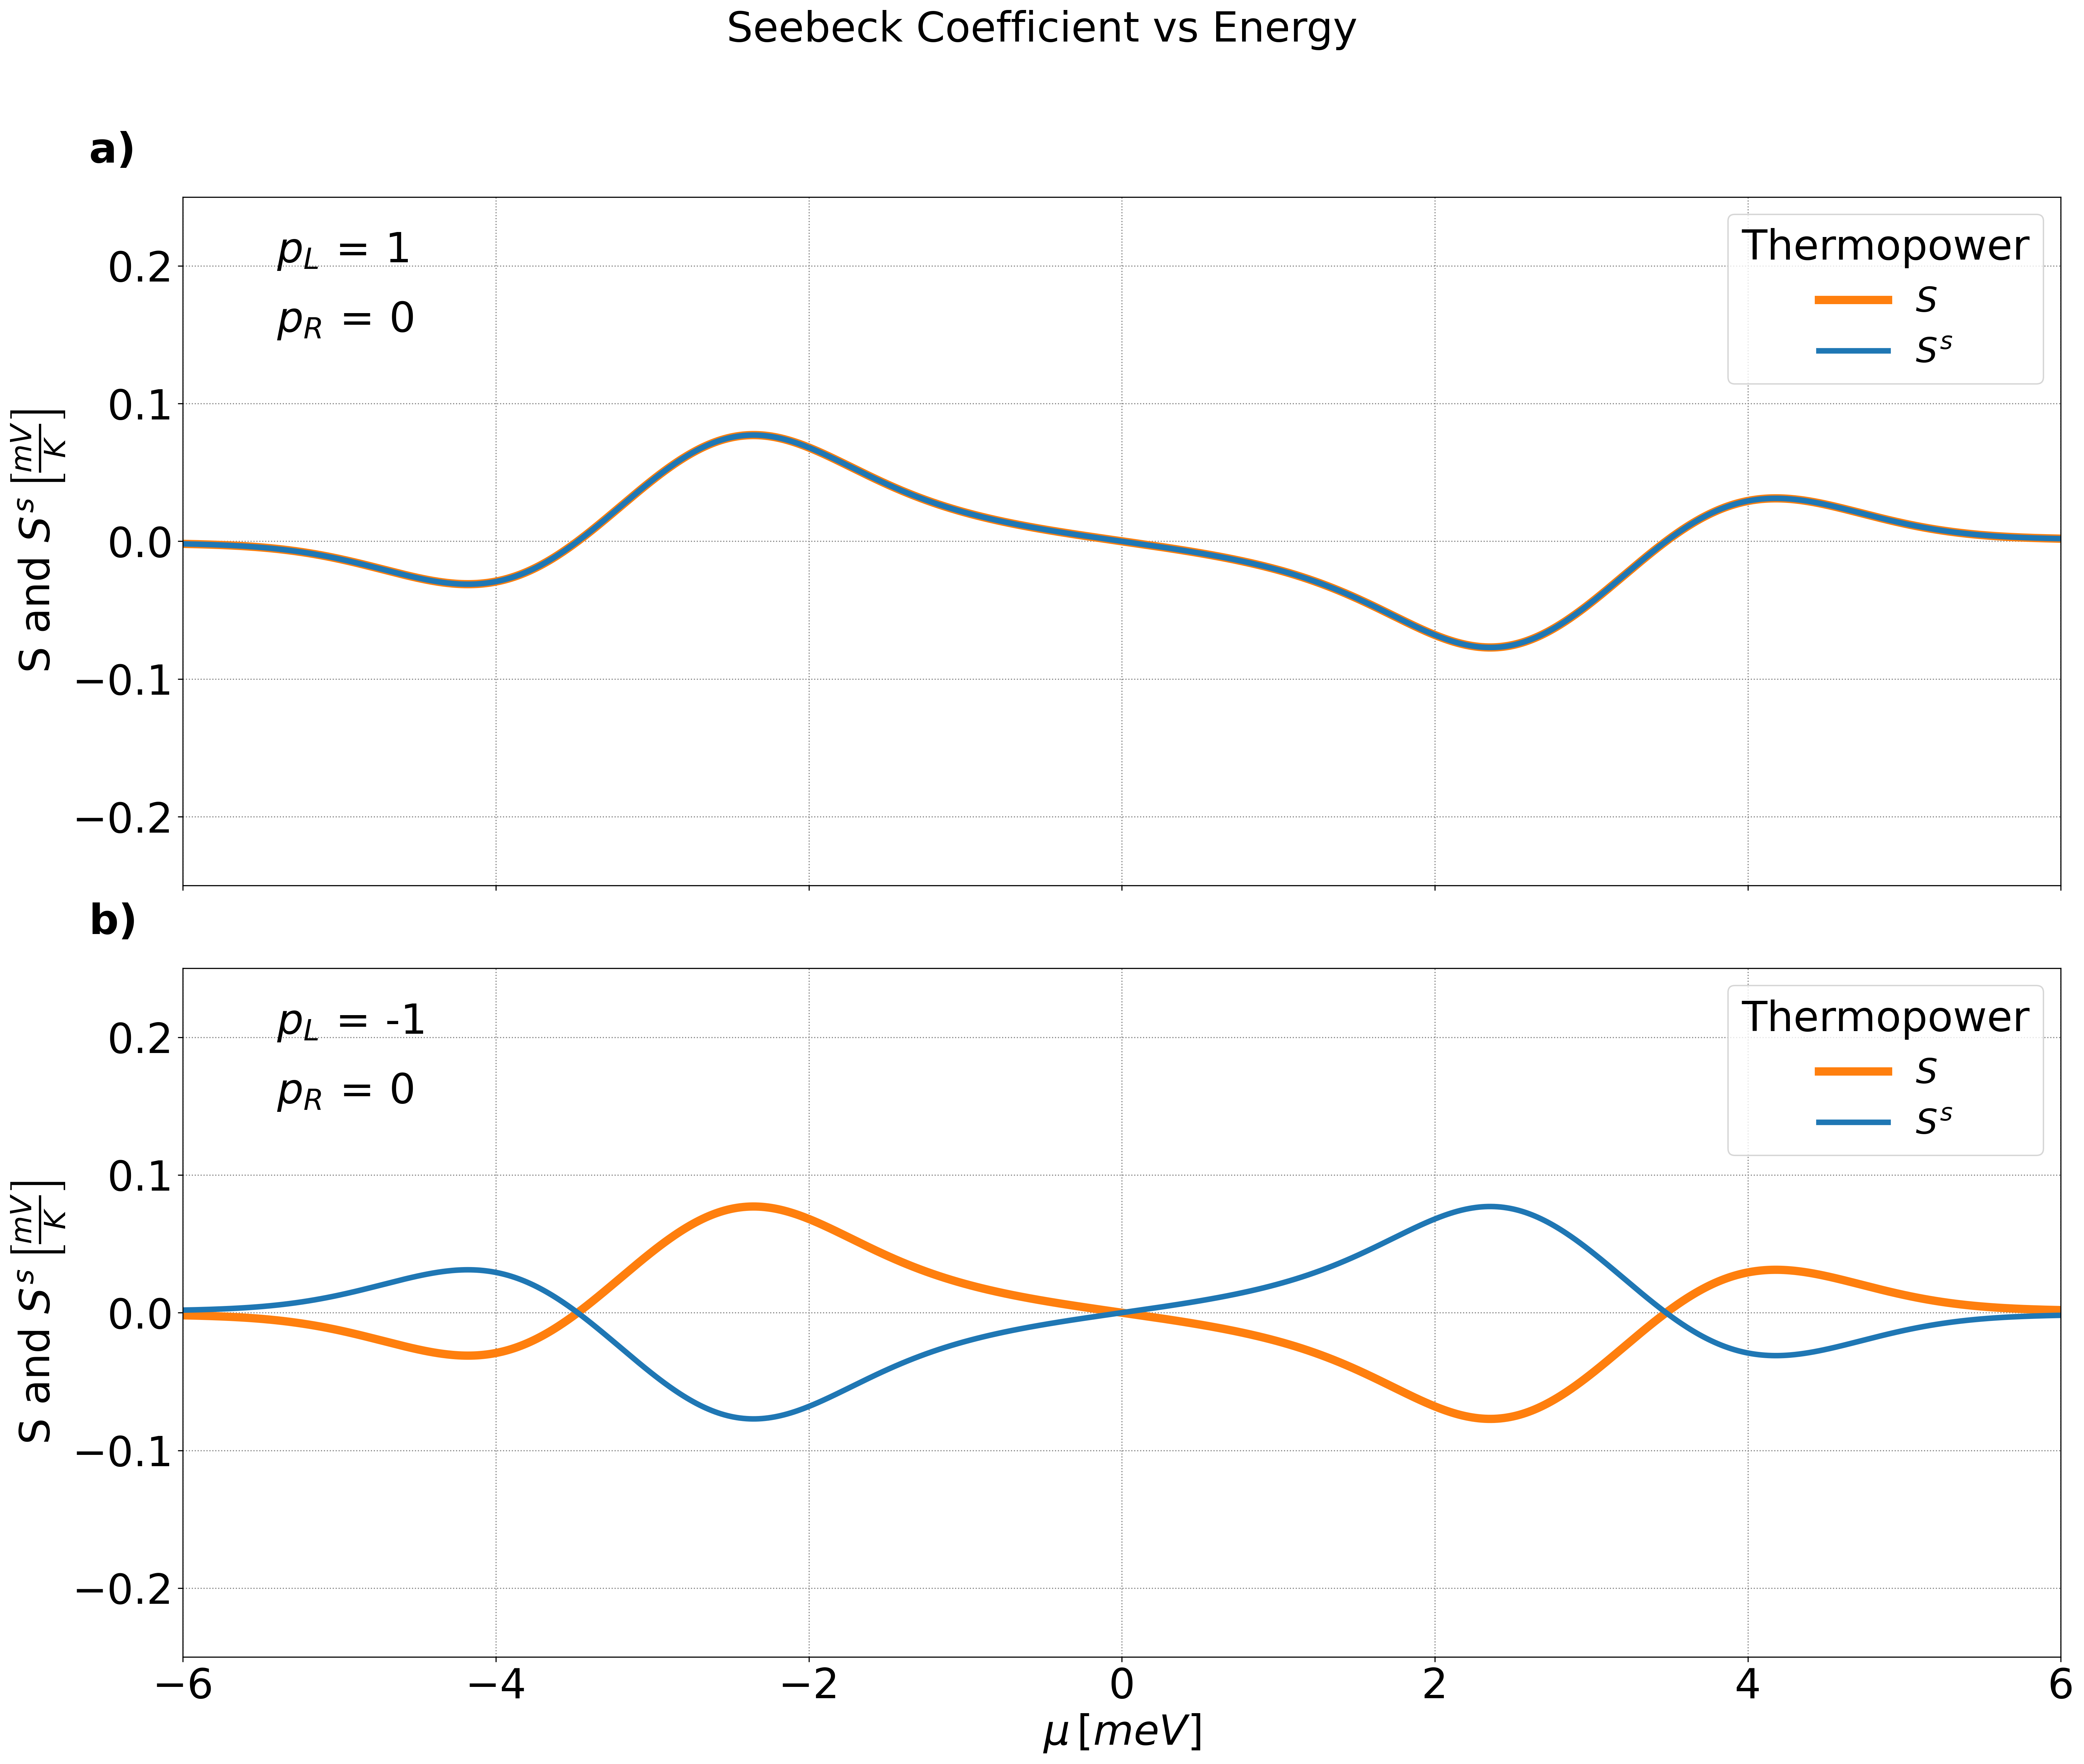

In [176]:
# Crear la figura y los ejes
fig = plt.figure(constrained_layout=True, figsize=(21, 18), dpi=300)

# these are matplotlib.patch.Patch properties
props = dict(boxstyle='round', facecolor='wheat', alpha=0)

# Set the grid for the subplots
gs = GridSpec(2, 1, figure=fig)

# Add the subplots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0])

ax1.grid(linestyle=':', color='grey')
ax1.plot(fermi_axis, -(1/2)*(seebeck_u_11 + seebeck_d_11), "#ff7f0e", label=r"$S$", linestyle="-", lw=6)
ax1.plot(fermi_axis, -(1/2)*(seebeck_u_11 - seebeck_d_11), "#1f77b4", label=r"$S^{s}$", linestyle="-", lw=4)
ax1.set_ylabel(r'S and $S^{s}\,\left[\frac{mV}{K} \right]$', fontsize=30)
ax1.text(0.05, 0.95, r"$p_{L}\,=\,$"+str(p_L_1), transform=ax1.transAxes, fontsize=30,
         verticalalignment='top', bbox=props)
ax1.text(0.05, 0.85, r"$p_{R}\,=\,$"+str(p_R_1), transform=ax1.transAxes, fontsize=30,
         verticalalignment='top', bbox=props)
ax1.legend(
    fontsize=25,
    title="Thermopower",
    title_fontsize=30,
    loc="upper right"
)
# Etiqueta a)
ax1.text(-0.05, 1.05, 'a)', transform=ax1.transAxes, fontsize=30, fontweight='bold')

ax2.grid(linestyle=':', color='grey')
ax2.plot(fermi_axis, -(1/2)*(seebeck_u_21 + seebeck_d_21), "#ff7f0e", label=r"$S$", linestyle="-", lw=6)
ax2.plot(fermi_axis, -(1/2)*(seebeck_u_21 - seebeck_d_21), "#1f77b4", label=r"$S^{s}$", linestyle="-", lw=4)
ax2.set_xlabel(r'$\mu\,[meV]$', fontsize=30)
ax2.set_ylabel(r'S and $S^{s}\,\left[\frac{mV}{K} \right]$', fontsize=30)
ax2.text(0.05, 0.95, r"$p_{L}\,=\,$"+str(p_L_2), transform=ax2.transAxes, fontsize=30,
         verticalalignment='top', bbox=props)
ax2.text(0.05, 0.85, r"$p_{R}\,=\,$"+str(p_R_2), transform=ax2.transAxes, fontsize=30,
         verticalalignment='top', bbox=props)
ax2.legend(
    fontsize=25,
    title="Thermopower",
    title_fontsize=30,
    loc="upper right"
)
# Etiqueta b)
ax2.text(-0.05, 1.05, 'b)', transform=ax2.transAxes, fontsize=30, fontweight='bold')

# Establecer límites para los subplots
ax1.set_xlim(-6, 6)
ax1.set_ylim(-0.25, 0.25)
ax2.set_xlim(-6, 6)
ax2.set_ylim(-0.25, 0.25)

# Ajustar el tamaño de las etiquetas de los ejes x e y
ax1.tick_params(axis='x', labelsize=30)
ax1.tick_params(axis='y', labelsize=30)
ax2.tick_params(axis='x', labelsize=30)
ax2.tick_params(axis='y', labelsize=30)

# Eliminar los números del eje x en el primer subplot
ax1.set_xticklabels([])

# Ajustar el diseño y mostrar los subplots
plt.suptitle("Seebeck Coefficient vs Energy", fontsize=30)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Guardar la imagen
#fig.savefig('final_thermopower_part1.jpg')

/home/franklin/miniconda3/envs/py37/lib/python3.7/site-packages/ipykernel_launcher.py:113: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.


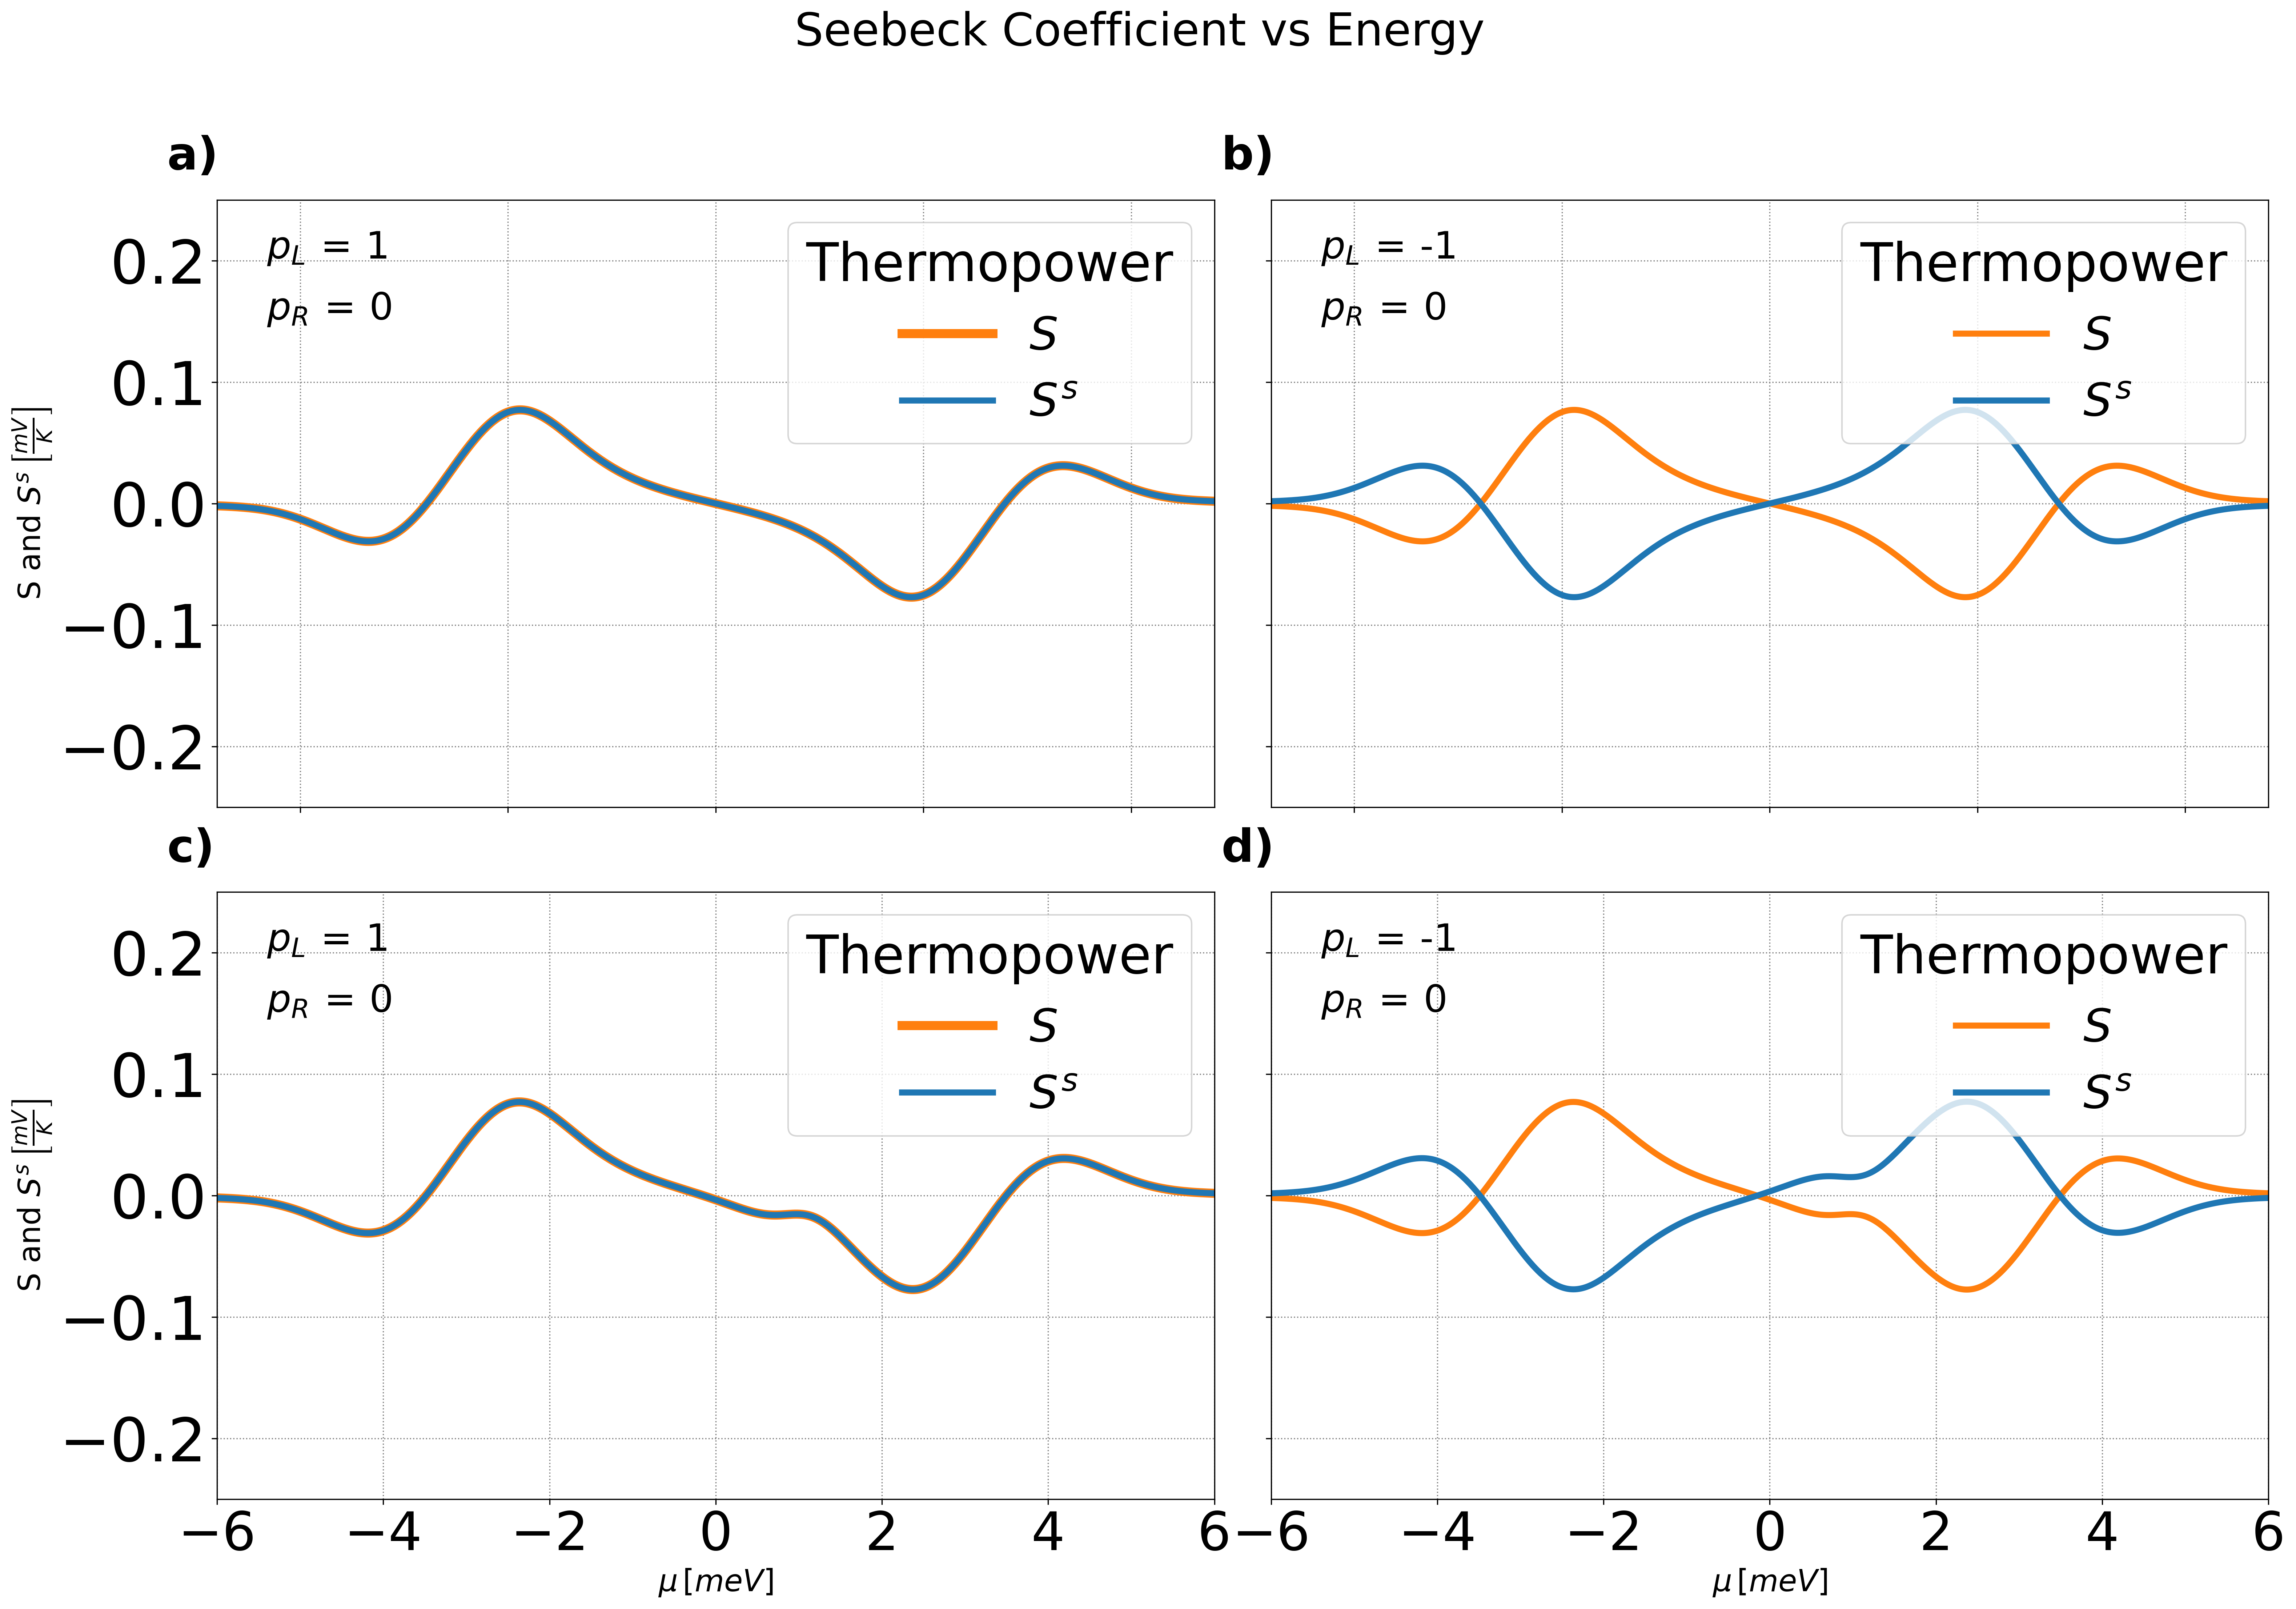

In [177]:
# Crear la figura y los ejes
fig = plt.figure(constrained_layout=True, figsize=(21, 15), dpi=300)

# these are matplotlib.patch.Patch properties
props = dict(boxstyle='round', facecolor='wheat', alpha=0)

# Set the grid for the subplots
gs = GridSpec(2, 2, figure=fig)

# Add the subplots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# Primer plot
ax1.grid(linestyle=':', color='grey')
ax1.plot(fermi_axis, -(1/2)*(seebeck_u_11 + seebeck_d_11), "#ff7f0e", label=r"$S$", linestyle="-", lw=6)
ax1.plot(fermi_axis, -(1/2)*(seebeck_u_11 - seebeck_d_11), "#1f77b4", label=r"$S^{s}$", linestyle="-", lw=4)
ax1.set_ylabel(r'S and $S^{s}\,\left[\frac{mV}{K} \right]$', fontsize=20)
ax1.text(0.05, 0.95, r"$p_{L}\,=\,$"+str(p_L_1), transform=ax1.transAxes, fontsize=25,
         verticalalignment='top', bbox=props)
ax1.text(0.05, 0.85, r"$p_{R}\,=\,$"+str(p_R_1), transform=ax1.transAxes, fontsize=25,
         verticalalignment='top', bbox=props)
ax1.legend(
    fontsize=30,
    title="Thermopower",
    title_fontsize=35,
    loc="upper right"
)
# Etiqueta a)
ax1.text(-0.05, 1.05, 'a)', transform=ax1.transAxes, fontsize=30, fontweight='bold')
ax1.set_xlim(-6, 6)
ax1.set_ylim(-0.25, 0.25)
ax1.tick_params(axis='x', labelsize=40)
ax1.tick_params(axis='y', labelsize=40)
ax1.set_xticklabels([])

# Segundo plot
ax2.grid(linestyle=':', color='grey')
ax2.plot(fermi_axis, -(1/2)*(seebeck_u_21 + seebeck_d_21), "#ff7f0e", label=r"$S$", linestyle="-", lw=4)
ax2.plot(fermi_axis, -(1/2)*(seebeck_u_21 - seebeck_d_21), "#1f77b4", label=r"$S^{s}$", linestyle="-", lw=4)
#ax2.set_xlabel(r'$\mu\,[meV]$', fontsize=20)
#ax2.set_ylabel(r'S and $S^{s}\,\left[\frac{mV}{K} \right]$', fontsize=20)
ax2.text(0.05, 0.95, r"$p_{L}\,=\,$"+str(p_L_2), transform=ax2.transAxes, fontsize=25,
         verticalalignment='top', bbox=props)
ax2.text(0.05, 0.85, r"$p_{R}\,=\,$"+str(p_R_2), transform=ax2.transAxes, fontsize=25,
         verticalalignment='top', bbox=props)
ax2.legend(
    fontsize=30,
    title="Thermopower",
    title_fontsize=35,
    loc="upper right"
)
# Etiqueta b)
ax2.text(-0.05, 1.05, 'b)', transform=ax2.transAxes, fontsize=30, fontweight='bold')
ax2.set_xlim(-6, 6)
ax2.set_ylim(-0.25, 0.25)
ax2.tick_params(axis='x', labelsize=40)
ax2.tick_params(axis='y', labelsize=40)
ax2.set_xticklabels([])
ax2.set_yticklabels([])

# Tercer plot
ax3.grid(linestyle=':', color='grey')
ax3.plot(fermi_axis, -(1/2)*(seebeck_u_1 + seebeck_d_1), "#ff7f0e", label=r"$S$", linestyle="-", lw=6)
ax3.plot(fermi_axis, -(1/2)*(seebeck_u_1 - seebeck_d_1), "#1f77b4", label=r"$S^{s}$", linestyle="-", lw=4)
ax3.set_ylabel(r'S and $S^{s}\,\left[\frac{mV}{K} \right]$', fontsize=20)
ax3.set_xlabel(r'$\mu\,[meV]$', fontsize=20)
ax3.text(0.05, 0.95, r"$p_{L}\,=\,$"+str(p_L_1), transform=ax3.transAxes, fontsize=25,
         verticalalignment='top', bbox=props)
ax3.text(0.05, 0.85, r"$p_{R}\,=\,$"+str(p_R_1), transform=ax3.transAxes, fontsize=25,
         verticalalignment='top', bbox=props)
ax3.legend(
    fontsize=30,
    title="Thermopower",
    title_fontsize=35,
    loc="upper right"
)
# Etiqueta c)
ax3.text(-0.05, 1.05, 'c)', transform=ax3.transAxes, fontsize=30, fontweight='bold')
ax3.set_xlim(-6, 6)
ax3.set_ylim(-0.25, 0.25)
ax3.tick_params(axis='x', labelsize=35)
ax3.tick_params(axis='y', labelsize=40)

# Cuarto plot
ax4.grid(linestyle=':', color='grey')
ax4.plot(fermi_axis, -(1/2)*(seebeck_u_2 + seebeck_d_2), "#ff7f0e", label=r"$S$", linestyle="-", lw=4)
ax4.plot(fermi_axis, -(1/2)*(seebeck_u_2 - seebeck_d_2), "#1f77b4", label=r"$S^{s}$", linestyle="-", lw=4)
ax4.set_xlabel(r'$\mu\,[meV]$', fontsize=20)
#ax4.set_ylabel(r'S and $S^{s}\,\left[\frac{mV}{K} \right]$', fontsize=20)
ax4.text(0.05, 0.95, r"$p_{L}\,=\,$"+str(p_L_2), transform=ax4.transAxes, fontsize=25,
         verticalalignment='top', bbox=props)
ax4.text(0.05, 0.85, r"$p_{R}\,=\,$"+str(p_R_2), transform=ax4.transAxes, fontsize=25,
         verticalalignment='top', bbox=props)
ax4.legend(
    fontsize=30,
    title="Thermopower",
    title_fontsize=35,
    loc="upper right"
)
# Etiqueta d)
ax4.text(-0.05, 1.05, 'd)', transform=ax4.transAxes, fontsize=30, fontweight='bold')
ax4.set_xlim(-6, 6)
ax4.set_ylim(-0.25, 0.25)
ax4.tick_params(axis='x', labelsize=35)
ax4.tick_params(axis='y', labelsize=40)
ax4.set_yticklabels([])

# Ajustar el diseño y mostrar los subplots
plt.suptitle("Seebeck Coefficient vs Energy", fontsize=30)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Guardar la imagen
fig.savefig('final_combined_thermopower_nochiral.jpg')
